# Plot all runs

Script to plot results from all 6 original runs together.

In [84]:
import logging
import warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import os
import pypsa
import cartopy.crs as ccrs
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.WARNING)

In [ ]:
# RESULTS SETTINGS
# Choose based on the results you want to plot:

results_folder = '../paper_results/'
#results_folder = '../test_results/'

path = '../result_data/'
fig_path = '../figures/'

In [ ]:
# SETTINGS

scenarios=['base', 'base_NZE', 'sudden', 'sudden_NZE', 'gradual', 'gradual_NZE']
scenarios_discount = ['base', 'sudden', 'gradual', 'base_007', 'sudden_007', 'gradual_007', 'base_010', 'sudden_010', 'gradual_010']
scenarios_gas = ['base', 'sudden','base_gas_low', 'sudden_gas_low','base_gas_high', 'sudden_gas_high']
scenarios_cost = ['base', 'base_cost', 'sudden', 'sudden_cost', 'gradual', 'gradual_cost']
scenarios_weather = ['base', 'base_2011', 'base_2018', 'sudden', 'sudden_2011', 'sudden_2018']
scenarios_4_nodes = ['gradual_NZE', 'gradual_NZE_4']

labels = ['BASE', 'BASE NZE', 'SC', 'SC NZE', 'GC', 'GC NZE']
labels_discount = ['BASE 4%', 'SC 4%', 'GC 4%', 'BASE 7%', 'SC 7%', 'GC 7%', 'BASE 10%', 'SC 10%', 'GC 10%']
labels_gas = ['BASE', 'SC', 'BASE GAS LOW 9%','SC GAS LOW 9%', 'BASE GAS HIGH 15%', 'SC GAS HIGH 15%']
labels_cost = ['BASE', 'BASE NEW COST', 'SC', 'SC NEW COST', 'GC', 'GC NEW COST']
labels_weather = ['BASE', 'BASE 2011', 'BASE 2018', 'SC', 'SC 2011', 'SC 2018']
labels_4_nodes = ['GC NZE', 'GC NZE 4']

base_file_name = 'base'
sudden_file_name = 'sudden'
gradual_file_name = 'gradual'
base_NZE_file_name = 'base_NZE'
sudden_NZE_file_name = 'sudden_NZE'
gradual_NZE_file_name = 'gradual_NZE'

base_007_file_name = 'base_007'
base_010_file_name = 'base_010'
sudden_007_file_name = 'sudden_007'
sudden_010_file_name = 'sudden_010'
gradual_007_file_name = 'gradual_007'
gradual_010_file_name = 'gradual_010'

base_cost_file_name = 'base_cost'
sudden_cost_file_name = 'sudden_cost'
gradual_cost_file_name = 'gradual_cost'

base_2011_file_name = 'base_2011'
base_2018_file_name = 'base_2018'
sudden_2011_file_name = 'sudden_2011'
sudden_2018_file_name = 'sudden_2018'

gradual_NZE_4_file_name = 'gradual_NZE_4'

network_path = results_folder + 'base/B_2024.nc'
four_node_network_path = results_folder + 'gradual_NZE_4/GCNZE_2024.nc'

years = [2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040]
first_year = years[0]
final_year = years[-1]

In [127]:
# COLORS

red1 = '#891D2D'
red2 = '#BA3B31'
orange = '#F58221'
yellow = '#FCAF19'
brown = '#440A15'
brown2 = '#B45419'
teal1 = '#032838'
teal2 = '#154655'
teal3 = '#527D77'
teal4 = '#8DB5AF'
teal1 = '#294839'
green1 = '#6DA08C'
green2 = '#6E966E'
green3 = '#A3BDA3'
beige1 = '#7A693B'
beige2 = '#A89677'
beige3 = '#D2CDAD'
grey1 = '#E7E7E7'
grey2 = '#D7D7D7'
grey3 = '#C6C6C6'
grey4 = '#939393'

carrier_colors = {
    'CCGT':      beige2,
    'OCGT':      beige3,
    'Biomass':   teal3,
    'Oil':       beige1,
    'Wind':      teal4,
    'Solar':     yellow,
    'Hydro':     teal2,
    'Battery':   brown,
    'Nbattery':  brown,
    'Geothermal':brown2,
    'Lost Load': grey4,
    'Demand':    grey1,
}

In [87]:
# Helper functions

def custom_autopct(pct):
    return f'{pct:.1f}%' if pct > 0.3 else ''

def rename_columns(df):
    new_names = ['Biomass',   'Oil',  'Wind',  'Solar'  ,'Hydro', 'Geothermal', 'Battery']
    old_names = ['biomass', 'oil', 'onwind', 'solar', 'hydro', 'geothermal', 'battery']
    name_map= dict(zip(old_names, new_names))
    df = df.rename(columns=name_map)
    return df

def get_colors(carriers):
    return [carrier_colors[carrier] for carrier in carriers]

def plot_power_mix_grid(
    scenario_csv_paths: dict,          # {label: filepath}, e.g. {"BASE": "base_power_mix.csv", ...}
    result_dir: str = '../result_data',
    save_path: str | None = None,      # e.g. '../figures/power_mix_2040.png'
    year_label: str = '2040',
):
    """
    Plot a 2x3 grid of power-mix donut charts, one per scenario.

    Parameters
    ----------
    scenario_csv_paths : dict
        Ordered dict mapping display label → CSV path.
        Expected order: BASE, SUDDEN, GRADUAL, BASE NZE, SUDDEN NZE, GRADUAL NZE
    result_dir : str
        Root folder for CSV files (prepended if path is relative).
    save_path : str | None
        If given, save figure to this path (PNG/PDF/SVG).
    year_label : str
        Appended to the figure caption.
    """
    #labels = list(scenario_csv_paths.keys())
    n_cols, n_rows = 3, 2

    plt.rcParams['font.size'] = 10
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 9))

    for idx, (label, csv_path) in enumerate(scenario_csv_paths.items()):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # ── load data ────────────────────────────────────────────────────────
        full_path = csv_path if os.path.isabs(csv_path) else os.path.join(result_dir, csv_path)
        df = pd.read_csv(full_path, index_col=0)
        df = rename_columns(df)

        values = df.iloc[0].values
        colors = get_colors(df.columns)

        # ── draw donut ───────────────────────────────────────────────────────
        wedges, texts, autotexts = ax.pie(
            values,
            autopct=custom_autopct,
            colors=colors,
            startangle=90,
            counterclock=False,
            wedgeprops=dict(width=0.3),
            pctdistance=1.15,
        )

        # hide tiny slice labels
        for autotext in autotexts:
            if autotext.get_text() <= '0.3%':
                autotext.set_visible(False)

        # white centre circle
        centre_circle = plt.Circle((0, 0), 0.70, fc='white')
        ax.add_artist(centre_circle)
        ax.axis('equal')

        # scenario label in the hole
        ax.text(
            0, 0, label,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            multialignment='center',
        )

    # ── shared legend ─────────────────────────────────────────────────────────
    # Build legend from the last parsed df so column order is consistent
    tech_names = list(df.columns)
    tech_colors = get_colors(df.columns)
    legend_handles = [
        mpatches.Patch(color=c, label=t)
        for t, c in zip(tech_names, tech_colors)
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=len(tech_names),
        bbox_to_anchor=(0.5, 0.04),
        frameon=False,
        fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])   # leave room for legend + caption

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')

    plt.show()


## Figure 3 (d)

(<matplotlib.collections.PatchCollection at 0x224881c2e90>,
 <matplotlib.collections.LineCollection at 0x22481cca3e0>)

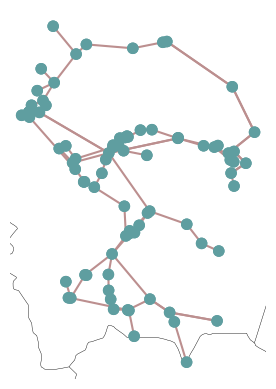

In [88]:
pypsa.Network(network_path).plot()

## Figure 4(b)

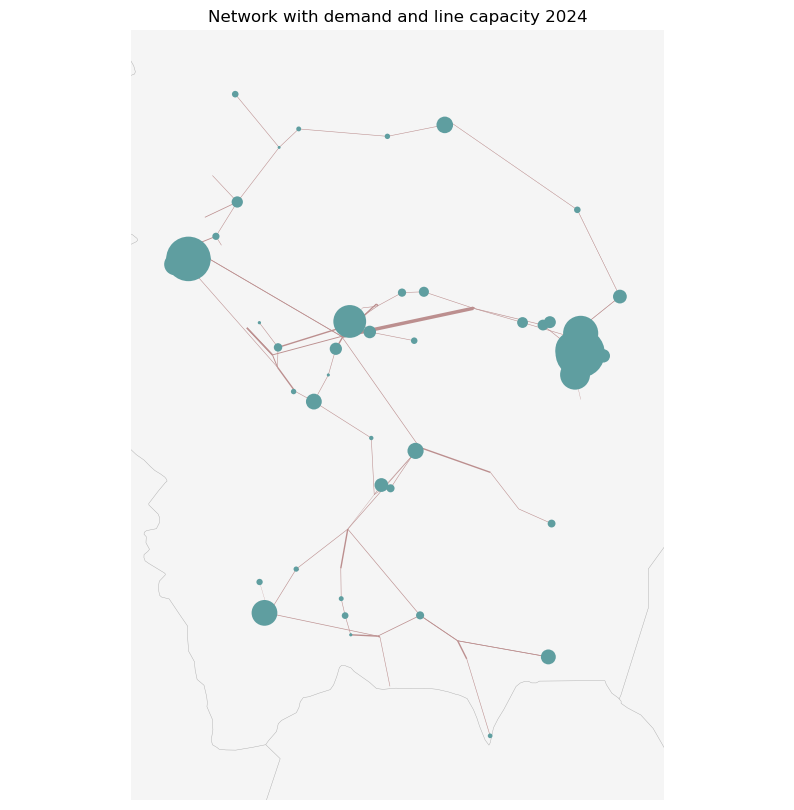

In [89]:
# PLOT NETWORK WITH DEMAND AND LINE CAPACITY

max_node_size = 0.1  # maximum size of a node for plotting purposes [used in plots]

def normalize_node_size(values, max_node_size=max_node_size):
    return values / values.max() * max_node_size

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },  
)

# Choose year to plot:
n = pypsa.Network(network_path)

n.plot(
    margin=0.1,
    ax=None,
    geomap=True,  
    projection=None,
    bus_colors="cadetblue",
    bus_alpha=1,
    bus_sizes=normalize_node_size(
        n.loads_t.p_set.sum().rename("load").rename_axis("bus")
    ),
    bus_cmap=None,
    line_colors="rosybrown",
    link_colors="darkseagreen",  
    transformer_colors="orange",
    line_widths=n.lines.s_nom_opt / 3e2,
    link_widths=1.5,
    transformer_widths=1.5,
    line_cmap=None,
    link_cmap=None,  
    transformer_cmap=None,
    flow=None,
    branch_components=None,
    layouter=None,
    title=f"Network with demand and line capacity {first_year}",
    boundaries=None,
    geometry=False,
    jitter=None,
    color_geomap=True,
)  # None or True

ax.axis("off")
plt.show()

## Figure 8

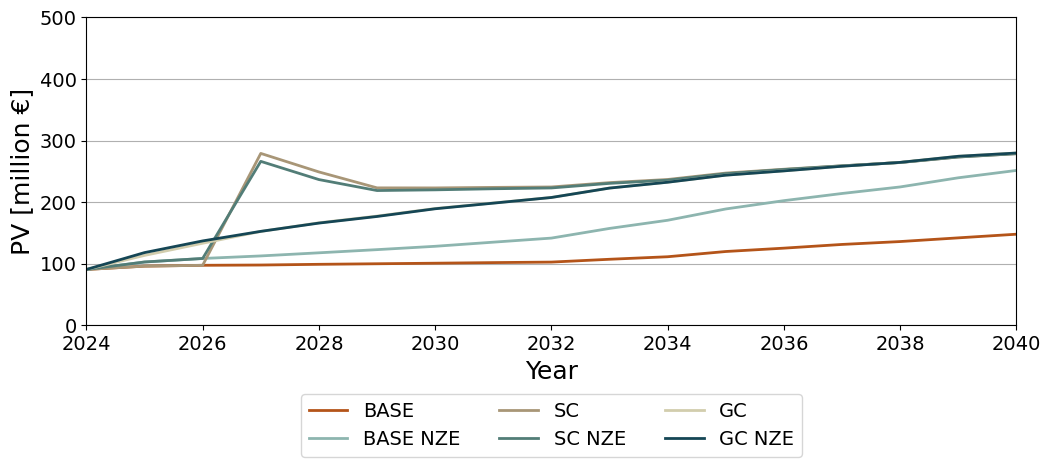

In [90]:
# PLOT PV OF COSTS

yearly_costs_all = pd.read_csv(path + 'total_costs.csv')
capcost = pd.read_csv(path + 'capcost.csv')

yearly_costs = yearly_costs_all[scenarios]
total_costs = yearly_costs.sum(axis=0) /1000
total_costs.columns = labels

costs_dict = {label: total_costs[i] for i, label in enumerate(yearly_costs.columns)}
costs_df = pd.DataFrame([costs_dict])

years = list(range(first_year, 2041))  # From year 2023 to 2037
yearly_costs.index = years

yearly_costs.columns = labels

colors_pv = [brown2, teal4, beige2, teal3, beige3, teal2]

plt.figure(figsize=(12, 4))  # Adjust the size as needed
for column in yearly_costs.columns:
    yearly_costs[column].plot(label=column, color=colors_pv[yearly_costs.columns.get_loc(column)], linewidth=2, fontsize=14)
plt.xlabel('Year', fontsize=18)
plt.ylabel('PV [million €]', fontsize=18)
plt.legend( loc='upper center', bbox_to_anchor=(0.5, -0.19), ncol=3, fontsize=14)
plt.grid(axis='y')
plt.ylim(0,500)
plt.xlim(first_year,final_year)
plt.savefig(fig_path + 'pv.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 9

     base  base_NZE    sudden  sudden_NZE   gradual  gradual_NZE
0  4.9815  2.272994  0.775744    0.688111  1.433695     1.277051


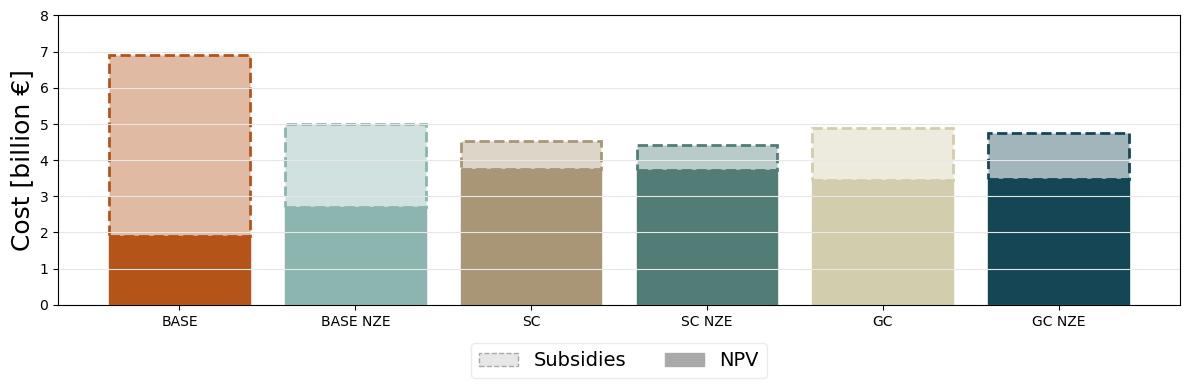

In [91]:
# PLOT NPV AND SUBSIDIES

subsidies_all = pd.read_csv(path + 'subsidies.csv')
subsidies = subsidies_all[scenarios]
subsidies = subsidies / 1000
print(subsidies)


# Create a new figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 4))

# The x-axis positions for each bar
index = np.arange(len(costs_df.columns))
colors_npv = [brown2, teal4, beige2, teal3, beige3, teal2]

total_costs_bars = ax.bar(index, costs_df.iloc[0], label='NPV', color=colors_npv, edgecolor=colors_npv)

fill_colors_with_alpha = [mcolors.to_rgba(color, alpha=0.4) for color in colors_npv]  # Fill colors with transparency
solid_edge_colors = [mcolors.to_rgba(color, alpha=1) for color in colors_npv]  # Edge colors without transparency

# Plotting the subsidies bars on top of the total costs (NPV)
subsidies_bars = ax.bar(index, subsidies.iloc[0], label='Subsidies', bottom=costs_df.iloc[0], 
                        color=fill_colors_with_alpha, edgecolor=solid_edge_colors, linestyle='--', linewidth=2)

ax.set_xticks(index, fontsize=14)
ax.set_xticklabels(labels, rotation=0)

# # Set the y-axis label
npv_patch = mpatches.Patch(color='darkgrey', label='NPV')
subsidies_patch = mpatches.Patch(facecolor=grey1, edgecolor='darkgrey', linestyle='--', linewidth=1, label='Subsidies')

# Create the legend with custom patches
plt.legend(handles=[subsidies_patch, npv_patch], loc='upper center', edgecolor=grey1, bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)
plt.ylabel('Cost [billion €]', fontsize=18)


# Add a title and a legend

plt.ylim(0,8)
plt.grid(axis='y', color=grey1)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig(fig_path + 'costs.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 10

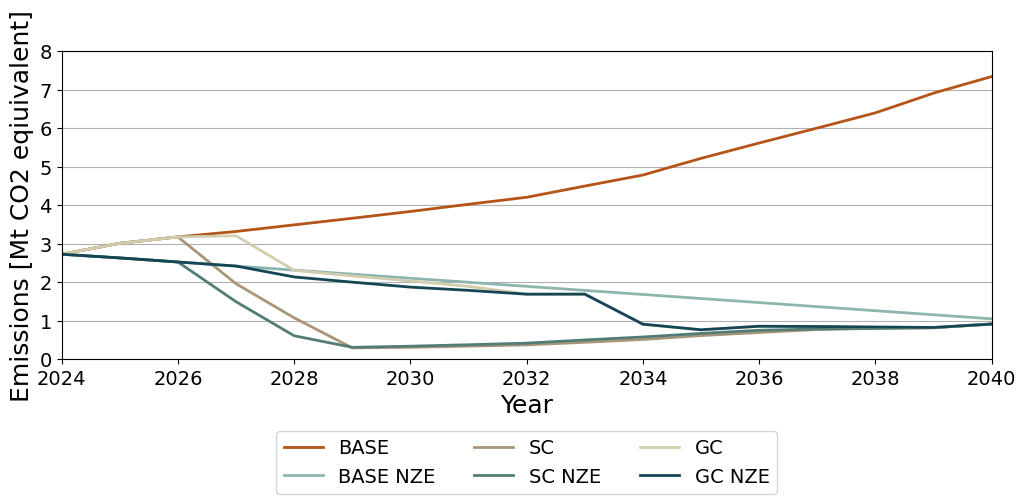

In [92]:
# PLOT EMISSIONS

emissions_all = pd.read_csv(path + 'emissions.csv')
emissions = emissions_all[scenarios]

years = list(range(first_year, final_year+1))  # From year 2023 to 2037
emissions.index = years

emissions.columns = labels
colors_emissions = [brown2, teal4, beige2, teal3, beige3, teal2]

plt.figure(figsize=(12, 4))  # Adjust the size as needed
for column in emissions.columns:
    emissions[column].plot(label=column, color=colors_emissions[emissions.columns.get_loc(column)], linewidth=2, fontsize=14)

plt.xlabel('Year', fontsize=18)
plt.ylabel('Emissions [Mt CO2 eqiuivalent]', fontsize=18)
plt.legend( loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=14)
plt.grid(axis='y')
plt.ylim(0,8)
plt.xlim(first_year,final_year)
plt.savefig(fig_path + 'emissions.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 11

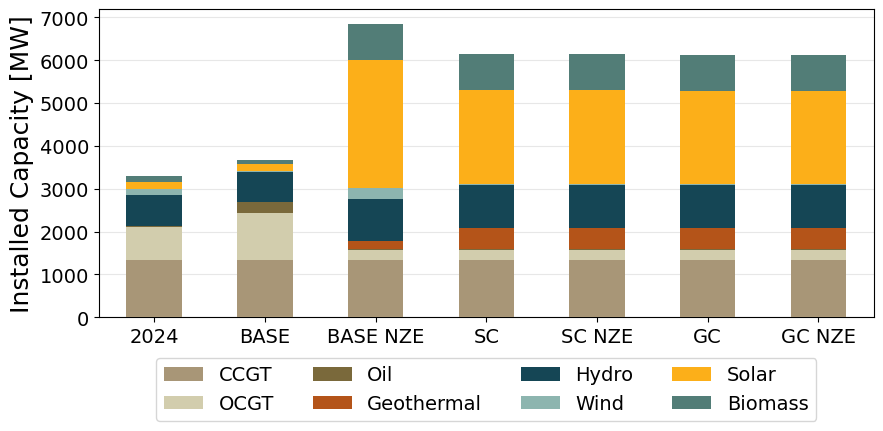

In [93]:
# PLOT FINAL CAPACITY

labels.insert(0, '2024')

base_start_capacity = pd.read_csv(path + base_file_name + '_24_final_capacity.csv', index_col=0)
base_final_capacity = pd.read_csv(path + base_file_name + '_final_capacity.csv', index_col=0)
base_final_capacity_cap = pd.read_csv(path + base_NZE_file_name + '_final_capacity.csv', index_col=0)
sudden_final_capacity = pd.read_csv(path + sudden_file_name + '_final_capacity.csv', index_col=0)
sudden_final_capacity_cap = pd.read_csv(path + sudden_NZE_file_name + '_final_capacity.csv', index_col=0)
gradual_final_capacity = pd.read_csv(path + gradual_file_name + '_final_capacity.csv', index_col=0)
gradual_final_capacity_cap = pd.read_csv(path + gradual_NZE_file_name + '_final_capacity.csv', index_col=0)

desired_order = ['CCGT', 'OCGT', 'Oil', 'Geothermal', 'Hydro', 'Wind', 'Solar', 'Biomass']

all_data = pd.concat([base_start_capacity, base_final_capacity,base_final_capacity_cap, sudden_final_capacity, sudden_final_capacity_cap,  gradual_final_capacity,gradual_final_capacity_cap], axis=0)
all_data = all_data[desired_order]
all_data.index = labels

ax = all_data.plot(kind='bar', stacked=True, figsize=(10, 4), color=get_colors(all_data.columns), legend=False, zorder=3, fontsize=14)   
plt.setp(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Installed Capacity [MW]', fontsize=18)   
ax.legend(title='Capacity Type')
plt.legend( loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=14)
plt.grid(axis='y', zorder=0, color=grey1)

plt.savefig(fig_path + 'final_capacity.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 12

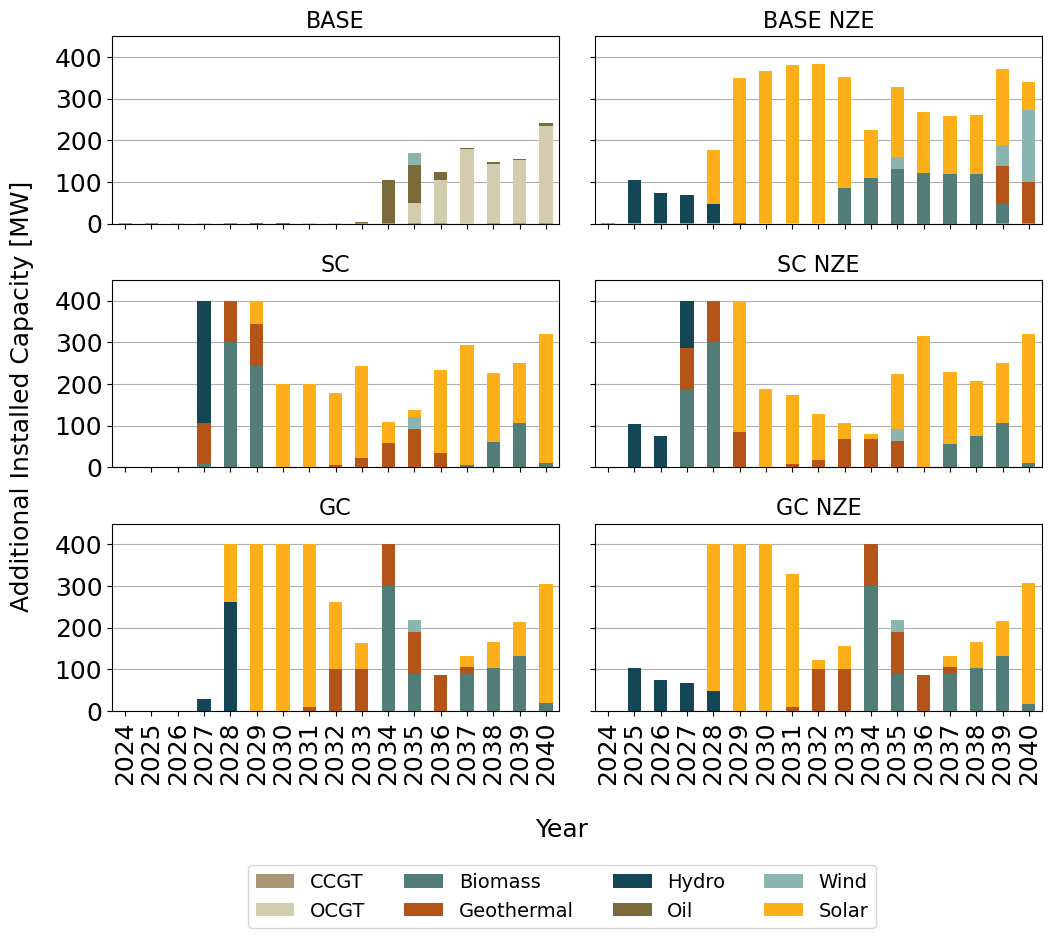

In [94]:
# PLOT NEW CAPACITY

labels = labels[1:]  # Remove '2024' from labels for the new capacity plot 

new_capacity_base = pd.read_csv(path + base_file_name + '_new_capacity.csv', index_col=0)
new_capacity_sudden = pd.read_csv(path + sudden_file_name + '_new_capacity.csv', index_col=0)
new_capacity_gradual = pd.read_csv(path + gradual_file_name + '_new_capacity.csv', index_col=0)
new_capacity_base_cap = pd.read_csv(path + base_NZE_file_name + '_new_capacity.csv', index_col=0)
new_capacity_sudden_cap = pd.read_csv(path + sudden_NZE_file_name + '_new_capacity.csv', index_col=0)
new_capacity_gradual_cap = pd.read_csv(path + gradual_NZE_file_name + '_new_capacity.csv', index_col=0)

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)

axes = axes.flatten()

new_capacity_scenarios = [
    ('BASE', new_capacity_base),
    ('BASE NZE', new_capacity_base_cap),
    ('SC', new_capacity_sudden),
    ('SC NZE', new_capacity_sudden_cap),
    ('GC', new_capacity_gradual),
    ('GC NZE', new_capacity_gradual_cap),

]


for ax, (title, capacity_data) in zip(axes, new_capacity_scenarios):
    capacity_data.plot.bar(stacked=True, ax=ax, color=get_colors(capacity_data.columns), legend=False, zorder=3, fontsize=18)
    ax.set_xlabel('')
    ax.set_xticks(range(len(capacity_data.index)))
    ax.set_xticklabels(capacity_data.index, rotation=90)
    ax.set_title(title, fontsize=16)
    ax.set_ylim(0, 450)
    ax.grid(axis='y', zorder=0)
    
# Only show y-ticks in left column
for i, ax in enumerate(axes):
    if i % 2 == 1:  # høyre kolonne
        ax.set_yticklabels([])
        ax.set_ylabel('')

# Set the x-axis label on the last subplot
fig.text(0.5, 0.01, 'Year', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Additional Installed Capacity [MW]', va='center', rotation='vertical', fontsize=18)

# Create a single shared legend
handles, tech = ax.get_legend_handles_labels()
fig.legend(handles, tech, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=4, fontsize=14)

# Adjust the layout
plt.subplots_adjust(hspace=0.3, top=0.9, bottom=0.15, wspace=0.08)
plt.savefig(fig_path + 'new_capacity.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 13

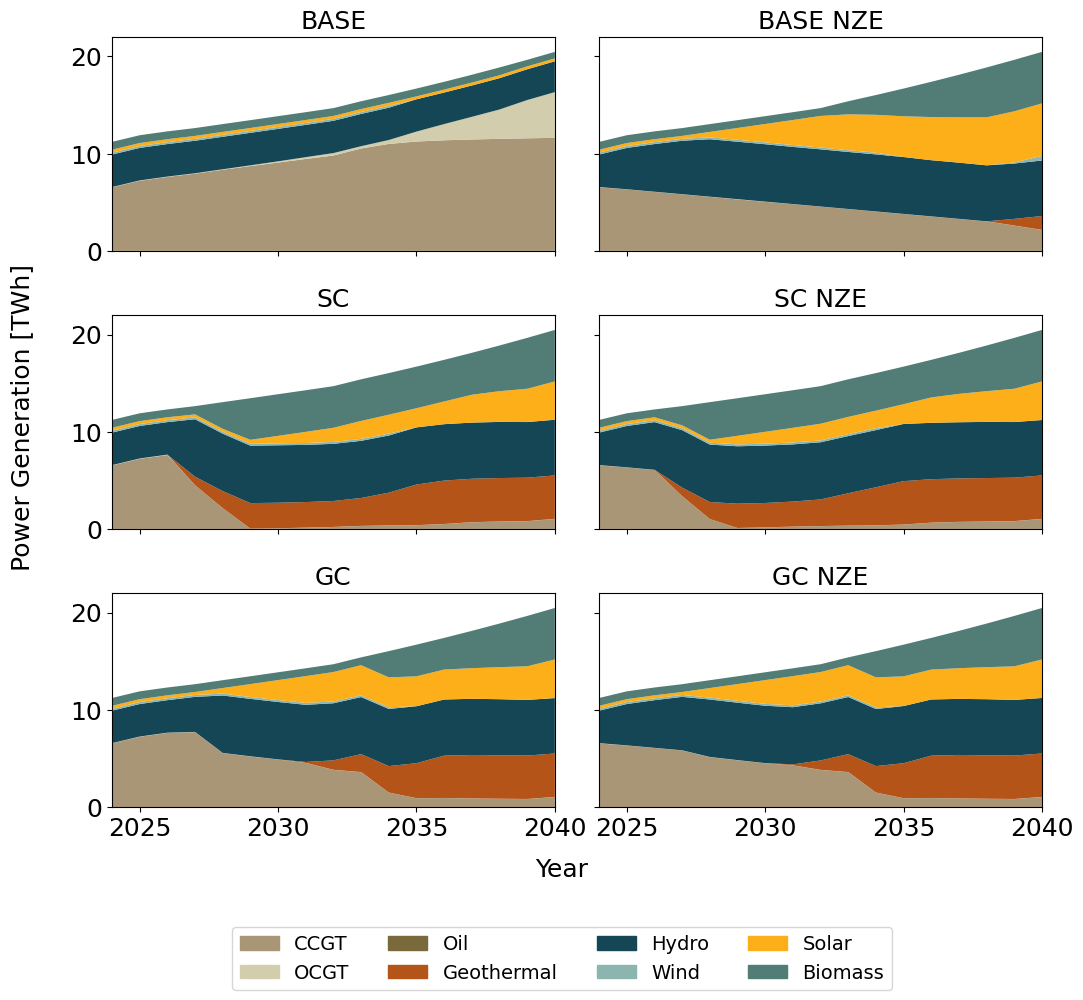

In [122]:
# PLOT POWER PRODUCTION

production_base = pd.read_csv(path + base_file_name + '_production.csv', index_col=0)
production_sudden = pd.read_csv(path + sudden_file_name + '_production.csv', index_col=0)
production_gradual = pd.read_csv(path + gradual_file_name + '_production.csv', index_col=0)
production_base_cap = pd.read_csv(path + base_NZE_file_name + '_production.csv', index_col=0)
production_sudden_cap = pd.read_csv(path + sudden_NZE_file_name + '_production.csv', index_col=0)
production_gradual_cap = pd.read_csv(path + gradual_NZE_file_name + '_production.csv', index_col=0)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True,
    gridspec_kw={'wspace': 0.1, 'hspace': 0.3})  # Adjust figsize as needed

# Flatten the 2D array of axes to 1D for easier iteration
axes = axes.flatten()

# Define your scenarios
scenarios = [
    (production_base, 'BASE'),
    (production_base_cap, 'BASE NZE'),
    (production_sudden, 'SC'),
    (production_sudden_cap, 'SC NZE'),
    (production_gradual, 'GC'),
    (production_gradual_cap, 'GC NZE')
]


# Loop through the scenarios to create each subplot
for ax, (production_data, title) in zip(axes, scenarios):
    # Ensure production_data is a DataFrame and not a numpy array
    if isinstance(production_data, pd.DataFrame):
        production_data.index = production_data.index.astype(str).str.strip().astype(int)

        ax.stackplot(production_data.index, production_data.T, 
                     colors=get_colors(production_data.columns), labels=production_data.columns)
        ax.set_ylim(0, 22)
        #ax.set_xlim(first_year, last_year)
        ax.set_title(title, fontsize=18)
        # rotate x-tick labels for better readability including all years
        ax.set_xlim(production_data.index.min(), production_data.index.max())
        xticks = production_data.index[::5]  # hvert 5. element i indeksen
        ax.set_xticks(xticks + 1)
        ax.set_xticklabels(xticks + 1, fontsize=18)
        #ax.tick_params(axis='both', which='major', labelsize=14) 
        ax.tick_params(axis='y', labelsize=18)
    else:
        print(f"Data for {title} is not in DataFrame format.")

# Fjern y-ticks i høyre kolonne
for i, ax in enumerate(axes):
    if i % 2 == 1:  # høyre kolonne
        ax.set_yticklabels([])
        ax.set_ylabel('')

# Set the shared x and y-axis labels
fig.text(0.5, 0.04, 'Year', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Power Generation [TWh]', va='center', rotation='vertical', fontsize=18)

tech = [label for label in production_base.columns if label != 'Nbattery']

patches = [mpatches.Patch(color=carrier_colors[label], label=label) for label in tech]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, fontsize=14)

#plt.subplots_adjust(hspace=0.3, bottom=0.15)

# Save the figure
plt.savefig(fig_path + 'power_prod.png', dpi=300, bbox_inches='tight') 
plt.show()

## Figure 14

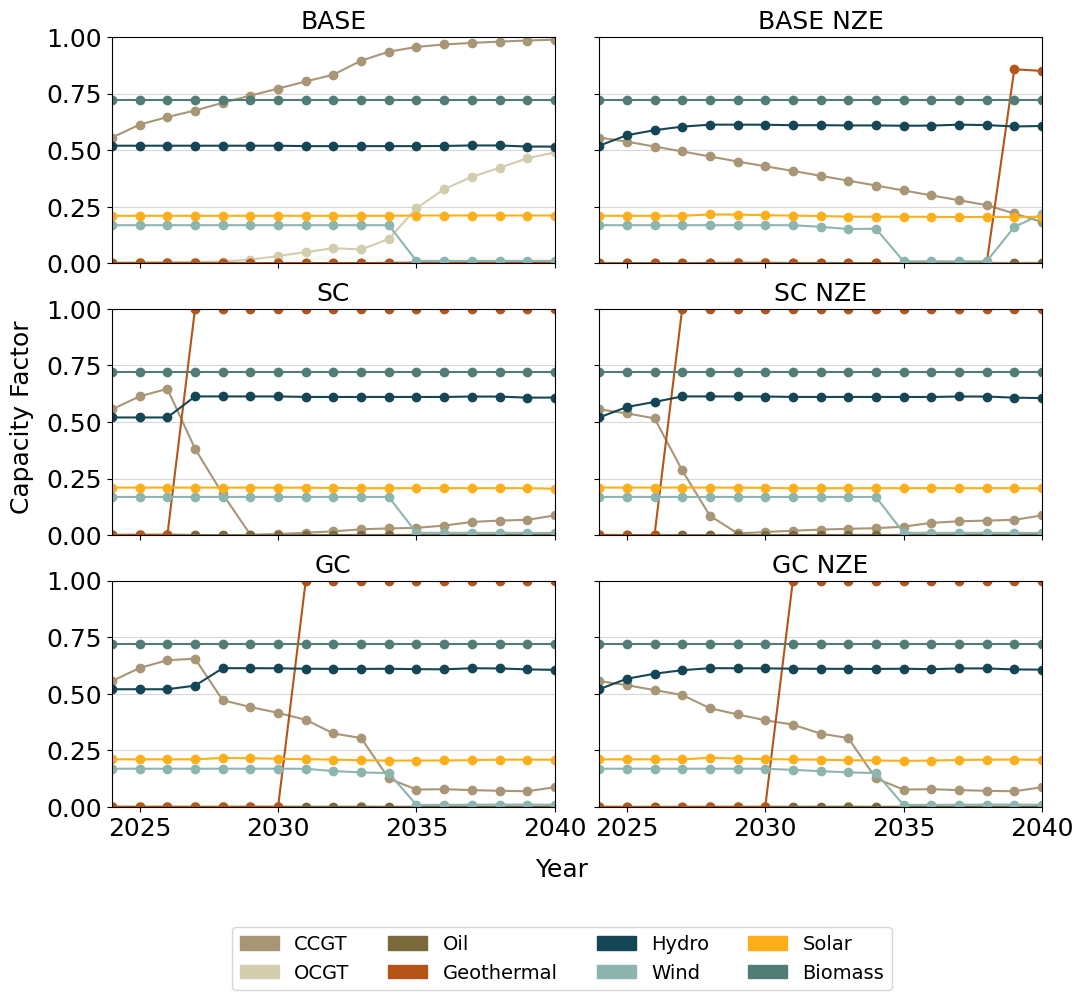

In [ ]:
# PLOT CAPACITY FACTORS

base_capacity_factor = pd.read_csv(path + base_file_name + '_capacity_factors.csv', index_col=0)
sudden_capacity_factor = pd.read_csv(path + sudden_file_name + '_capacity_factors.csv', index_col=0)
gradual_capacity_factor = pd.read_csv(path + gradual_file_name + '_capacity_factors.csv', index_col=0)
base_capacity_factor_cap = pd.read_csv(path + base_NZE_file_name + '_capacity_factors.csv', index_col=0)
sudden_capacity_factor_cap = pd.read_csv(path + sudden_NZE_file_name + '_capacity_factors.csv', index_col=0)
gradual_capacity_factor_cap = pd.read_csv(path + gradual_NZE_file_name + '_capacity_factors.csv', index_col=0)

desired_order = ['CCGT', 'OCGT', 'Oil', 'Geothermal', 'Hydro', 'Wind', 'Solar', 'Biomass']

scenarios_cp = {
    'BASE': base_capacity_factor,
    'BASE NZE': base_capacity_factor_cap,
    'SC': sudden_capacity_factor,
    'SC NZE': sudden_capacity_factor_cap,
    'GC': gradual_capacity_factor,
    'GC NZE': gradual_capacity_factor_cap
}

# Create subplots - one for each scenario
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten if needed

used_labels = set()

# Plot each scenario in its own subplot
for ax, (title, scenario) in zip(axes, scenarios_cp.items()):
    for carrier_name in desired_order:
        if carrier_name in scenario.columns:
            ax.plot(scenario.index, scenario[carrier_name], label=carrier_name, color=carrier_colors[carrier_name], marker='o')
            used_labels.add(carrier_name)
        else:
            print(f"'{carrier_name}' not found in '{title}' scenario")
    ax.set_ylim(0,1)
    ax.set_xlim(first_year,final_year)
    ax.set_title(title, fontdict={'fontsize':18})
    ax.grid(axis='y', color=grey2)
    # set x-ticks every 5 years
    xticks = list(range(first_year + 1, final_year + 1, 5))
    ax.set_xticks(xticks)
    # set font size for x and y ticks
    ax.tick_params(axis='both', which='major', labelsize=18)

# Set common labels and title
fig.text(0.5, 0.04, 'Year', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Capacity Factor', va='center', rotation='vertical', fontsize=18)

# Only include used labels in the legend
handles = [mpatches.Patch(color=carrier_colors[label], label=label) for label in desired_order if label in used_labels]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=4, fontsize=14)
plt.subplots_adjust(wspace=0.1)
plt.savefig(fig_path + 'capacity_factors.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 15

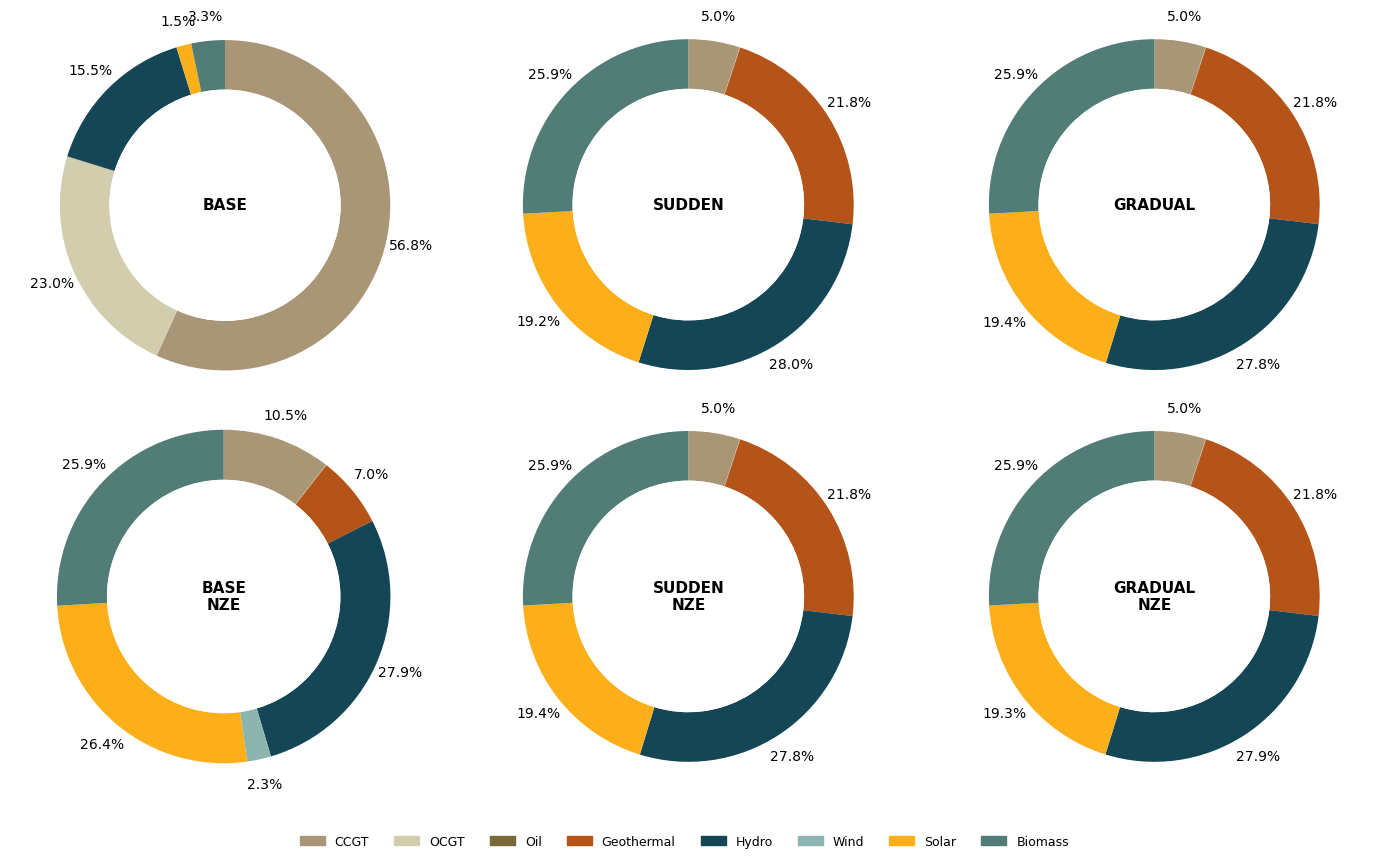

In [97]:
# PLOT POWER MIXES

scenarios = {
    "BASE":         "base_power_mix.csv",
    "SUDDEN":       "sudden_power_mix.csv",
    "GRADUAL":      "gradual_power_mix.csv",
    "BASE\nNZE":    "base_NZE_power_mix.csv",
    "SUDDEN\nNZE":  "sudden_NZE_power_mix.csv",
    "GRADUAL\nNZE": "gradual_NZE_power_mix.csv",
}

plot_power_mix_grid(
    scenario_csv_paths=scenarios,
    result_dir='../result_data',
    year_label='2040',
)

## Figure 16

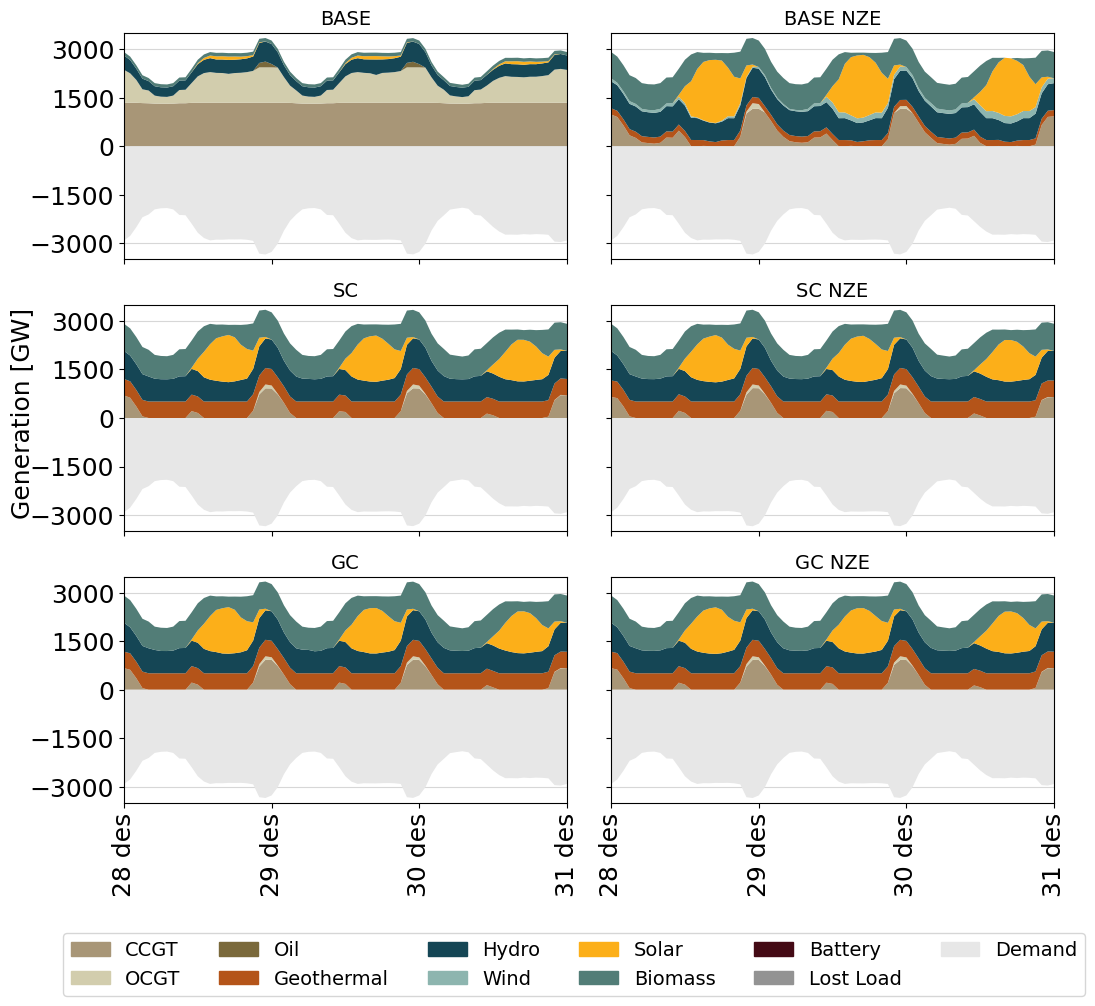

In [128]:
# PLOT DISPATCH

snapshot_base = pd.read_csv(path + base_file_name + '_snapshots.csv', index_col=0, parse_dates=True)
snapshot_sudden = pd.read_csv(path + sudden_file_name + '_snapshots.csv', index_col=0, parse_dates=True)
snapshot_gradual = pd.read_csv(path + gradual_file_name + '_snapshots.csv', index_col=0, parse_dates=True)
snapshot_base_cap = pd.read_csv(path + base_NZE_file_name + '_snapshots.csv', index_col=0, parse_dates=True)
snapshot_sudden_cap = pd.read_csv(path + sudden_NZE_file_name + '_snapshots.csv', index_col=0, parse_dates=True)
snapshot_gradual_cap = pd.read_csv(path + gradual_NZE_file_name + '_snapshots.csv', index_col=0, parse_dates=True)

first_date = "2013-12-28"
second_date = "2013-12-31"
start_date = pd.to_datetime(first_date)
end_date = pd.to_datetime(second_date)

# columns to stack (positive generation)
gen_carriers    = ['CCGT', 'OCGT', 'Oil', 'Geothermal', 'Hydro', 'Wind', 'Solar', 'Biomass', 'Battery', 'Lost Load']
demand_carriers = ['Demand', 'Nbattery']

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

scenarios = [
    ('BASE',     snapshot_base),
    ('BASE NZE', snapshot_base_cap),
    ('SC',       snapshot_sudden),
    ('SC NZE',   snapshot_sudden_cap),
    ('GC',       snapshot_gradual),
    ('GC NZE',   snapshot_gradual_cap),
]

for ax, (title, data) in zip(axes, scenarios):
    ax.stackplot(data.index,
                 [data[c] for c in gen_carriers],
                 colors=[carrier_colors[c] for c in gen_carriers],
                 zorder=2)
    ax.stackplot(data.index,
                 [data[c] for c in demand_carriers],
                 colors=[carrier_colors[c] for c in demand_carriers],
                 zorder=2)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(start_date, end_date)
    ax.grid(axis='y', color=grey2)
    ax.set_ylim(-3500, 3500)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.tick_params(axis='x', labelrotation=90, labelsize=18)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_yticks([-3000, -1500, 0, 1500, 3000])

fig.text(0.04, 0.5, 'Generation [GW]', va='center', rotation='vertical', ha='center', fontsize=18)

# legend — all carriers except Nbattery
legend_carriers = [c for c in gen_carriers + demand_carriers if c != 'Nbattery']
patches = [mpatches.Patch(color=carrier_colors[c], label=c) for c in legend_carriers]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=6, fontsize=14)

plt.subplots_adjust(wspace=0.1)
plt.savefig(fig_path + 'snapshots.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 17

     base    sudden   gradual  base_007  sudden_007  gradual_007  base_010  \
0  4.9815  0.775744  1.433695   3.95288    0.754131      1.47535  3.126261   

   sudden_010  gradual_010  
0    0.734248     1.409307  


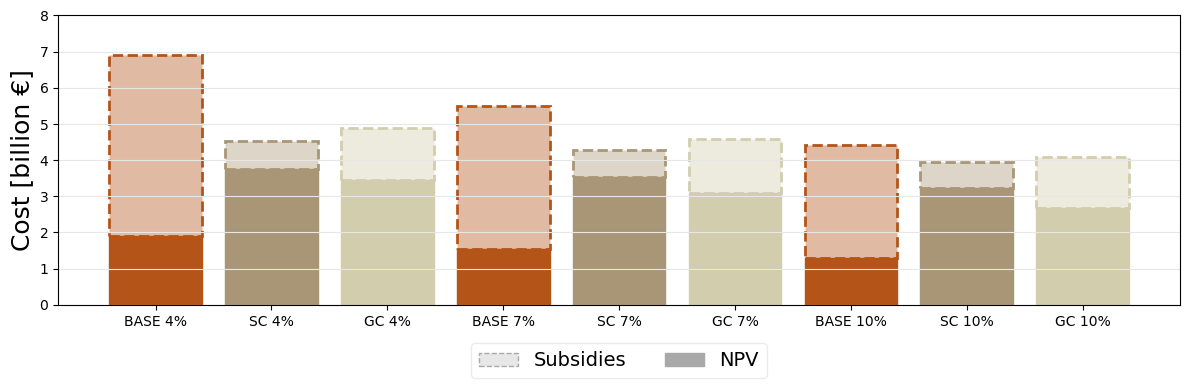

In [99]:
# PLOT NPV AND SUBSIDIES DISCOUNT RATE SENSITIVITY ANALYSIS

yearly_costs_all = pd.read_csv(path + 'total_costs.csv')
capcost = pd.read_csv(path + 'capcost.csv')

yearly_costs_discount = yearly_costs_all[scenarios_discount]
total_costs_discount = yearly_costs_discount.sum(axis=0) /1000
total_costs_discount.columns = labels_discount

costs_dict_discount = {label: total_costs_discount[i] for i, label in enumerate(yearly_costs_discount.columns)}
costs_df_discount = pd.DataFrame([costs_dict_discount])

subsidies_all = pd.read_csv(path + 'subsidies.csv')
subsidies_discount = subsidies_all[scenarios_discount]
subsidies_discount = subsidies_discount / 1000
print(subsidies_discount)
#subsidies_discount.columns = labels_discount

# Create a new figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 4))

# The x-axis positions for each bar
index = np.arange(len(costs_df_discount.columns))
colors_discount = [brown2, beige2, beige3, brown2, beige2, beige3, brown2, beige2, beige3]

total_costs_bars = ax.bar(index, costs_df_discount.iloc[0], label='NPV', color=colors_discount, edgecolor=colors_discount)

fill_colors_with_alpha = [mcolors.to_rgba(color, alpha=0.4) for color in colors_discount]  # Fill colors with transparency
solid_edge_colors = [mcolors.to_rgba(color, alpha=1) for color in colors_discount]  # Edge colors without transparency



# Plotting the subsidies bars on top of the total costs (NPV)
subsidies_bars = ax.bar(index, subsidies_discount.iloc[0], label='Subsidies', bottom=costs_df_discount.iloc[0], 
                        color=fill_colors_with_alpha, edgecolor=solid_edge_colors, linestyle='--', linewidth=2)

ax.set_xticks(index, fontsize=14)
ax.set_xticklabels(labels_discount, rotation=0)

# # Set the y-axis label
npv_patch = mpatches.Patch(color='darkgrey', label='NPV')
subsidies_patch = mpatches.Patch(facecolor=grey1, edgecolor='darkgrey', linestyle='--', linewidth=1, label='Subsidies')

# Create the legend with custom patches
plt.legend(handles=[subsidies_patch, npv_patch], loc='upper center', edgecolor=grey1, bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)
plt.ylabel('Cost [billion €]', fontsize=18)


# Add a title and a legend

plt.ylim(0,8)
plt.grid(axis='y', color=grey1)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig(fig_path + 'discount/'+'costs.png', dpi=300, bbox_inches='tight')
plt.show()

## Table 5

In [100]:
# RENEWABLES SHARE TABLE DISCOUNT RATE SENSITIVITY ANALYSIS

production_base = pd.read_csv(path + base_file_name + '_production.csv', index_col=0)
production_base_007 = pd.read_csv(path + base_007_file_name + '_production.csv', index_col=0)
production_base_010 = pd.read_csv(path + base_010_file_name + '_production.csv', index_col=0)
production_sudden = pd.read_csv(path + sudden_file_name + '_production.csv', index_col=0)
production_sudden_007 = pd.read_csv(path + sudden_007_file_name + '_production.csv', index_col=0)
production_sudden_010 = pd.read_csv(path + sudden_010_file_name + '_production.csv', index_col=0)
production_gradual = pd.read_csv(path + gradual_file_name + '_production.csv', index_col=0)
production_gradual_007 = pd.read_csv(path + gradual_007_file_name + '_production.csv', index_col=0)
production_gradual_010 = pd.read_csv(path + gradual_010_file_name + '_production.csv', index_col=0)

renewables_share_base = (production_base['Wind'].sum() + production_base['Solar'].sum() + production_base['Hydro'].sum() + production_base['Biomass'].sum() + production_base['Geothermal'].sum()) / production_base.sum().sum() * 100
renewables_share_sudden = (production_sudden['Wind'].sum() + production_sudden['Solar'].sum() + production_sudden['Hydro'].sum() + production_sudden['Biomass'].sum() + production_sudden['Geothermal'].sum()) / production_sudden.sum().sum() * 100
renewables_share_gradual = (production_gradual['Wind'].sum() + production_gradual['Solar'].sum() + production_gradual['Hydro'].sum() + production_gradual['Biomass'].sum() + production_gradual['Geothermal'].sum()) / production_gradual.sum().sum() * 100
renewables_share_base_007 = (production_base_007['Wind'].sum() + production_base_007['Solar'].sum() + production_base_007['Hydro'].sum() + production_base_007['Biomass'].sum() + production_base_007['Geothermal'].sum()) / production_base_007.sum().sum() * 100
renewables_share_sudden_007 = (production_sudden_007['Wind'].sum() + production_sudden_007['Solar'].sum() + production_sudden_007['Hydro'].sum() + production_sudden_007['Biomass'].sum() + production_sudden_007['Geothermal'].sum()) / production_sudden_007.sum().sum() * 100
renewables_share_gradual_007 = (production_gradual_007['Wind'].sum() + production_gradual_007['Solar'].sum() + production_gradual_007['Hydro'].sum() + production_gradual_007['Biomass'].sum() + production_gradual_007['Geothermal'].sum()) / production_gradual_007.sum().sum() * 100
renewables_share_base_010 = (production_base_010['Wind'].sum() + production_base_010['Solar'].sum() + production_base_010['Hydro'].sum() + production_base_010['Biomass'].sum() + production_base_010['Geothermal'].sum()) / production_base_010.sum().sum() * 100
renewables_share_sudden_010 = (production_sudden_010['Wind'].sum() + production_sudden_010['Solar'].sum() + production_sudden_010['Hydro'].sum() + production_sudden_010['Biomass'].sum() + production_sudden_010['Geothermal'].sum()) / production_sudden_010.sum().sum() * 100
renewables_share_gradual_010 = (production_gradual_010['Wind'].sum() + production_gradual_010['Solar'].sum() + production_gradual_010['Hydro'].sum() + production_gradual_010['Biomass'].sum() + production_gradual_010['Geothermal'].sum()) / production_gradual_010.sum().sum() * 100

renewables_share_df = pd.DataFrame({
    'Scenario': labels_discount,
    'Renewables share [%]': [renewables_share_base.round(2), renewables_share_sudden.round(2), renewables_share_gradual.round(2), renewables_share_base_007.round(2), renewables_share_sudden_007.round(2), renewables_share_gradual_007.round(2), renewables_share_base_010.round(2), renewables_share_sudden_010.round(2), renewables_share_gradual_010.round(2)]
})

renewables_share_df

,Scenario,Renewables share [%]
0,BASE 4%,29.52
1,SC 4%,87.14
2,GC 4%,75.48
3,BASE 7%,29.52
4,SC 7%,84.47
5,GC 7%,65.93
6,BASE 10%,32.31
7,SC 10%,65.44
8,GC 10%,56.33


## Figure 18

     base    sudden  base_gas_low  sudden_gas_low  base_gas_high  \
0  4.9815  0.775744      4.337227        0.649264       9.829706   

   sudden_gas_high  
0         1.191224  


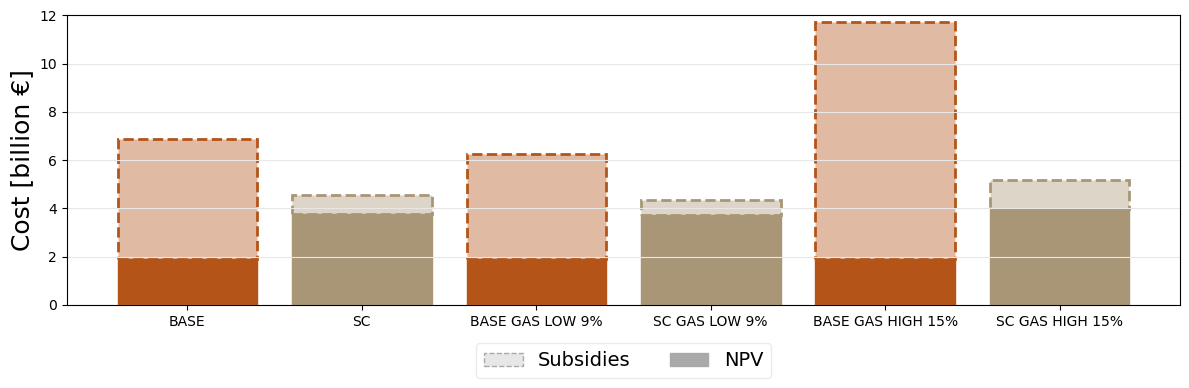

In [101]:
# PLOT NPV AND SUBSIDIES GAS SENSITIVITY ANALYSIS

yearly_costs_all = pd.read_csv(path + 'total_costs.csv')
capcost = pd.read_csv(path + 'capcost.csv')

yearly_costs_gas = yearly_costs_all[scenarios_gas]
total_costs_gas = yearly_costs_gas.sum(axis=0) /1000
total_costs_gas.columns = labels_gas

costs_dict_gas = {label: total_costs_gas[i] for i, label in enumerate(yearly_costs_gas.columns)}
costs_df_gas = pd.DataFrame([costs_dict_gas])

subsidies_all = pd.read_csv(path + 'subsidies.csv')
subsidies_gas = subsidies_all[scenarios_gas]
subsidies_gas = subsidies_gas / 1000
print(subsidies_gas)
#subsidies_gas.columns = labels_gas

# Create a new figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 4))

# The x-axis positions for each bar
index = np.arange(len(costs_df_gas.columns))
colors = [brown2, beige2, brown2, beige2, brown2, beige2]

total_costs_bars = ax.bar(index, costs_df_gas.iloc[0], label='NPV', color=colors, edgecolor=colors)

fill_colors_with_alpha = [mcolors.to_rgba(color, alpha=0.4) for color in colors]  # Fill colors with transparency
solid_edge_colors = [mcolors.to_rgba(color, alpha=1) for color in colors]  # Edge colors without transparency



# Plotting the subsidies bars on top of the total costs (NPV)
subsidies_bars = ax.bar(index, subsidies_gas.iloc[0], label='Subsidies', bottom=costs_df_gas.iloc[0], 
                        color=fill_colors_with_alpha, edgecolor=solid_edge_colors, linestyle='--', linewidth=2)

ax.set_xticks(index, fontsize=14)
ax.set_xticklabels(labels_gas, rotation=0)

# # Set the y-axis label
npv_patch = mpatches.Patch(color='darkgrey', label='NPV')
subsidies_patch = mpatches.Patch(facecolor=grey1, edgecolor='darkgrey', linestyle='--', linewidth=1, label='Subsidies')

# Create the legend with custom patches
plt.legend(handles=[subsidies_patch, npv_patch], loc='upper center', edgecolor=grey1, bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)
plt.ylabel('Cost [billion €]', fontsize=18)


# Add a title and a legend

plt.ylim(0,12)
plt.grid(axis='y', color=grey1)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig(fig_path + 'gas/' + 'costs.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 19

     base  base_cost    sudden  sudden_cost   gradual  gradual_cost
0  4.9815    4.51663  0.775744     0.725729  1.433695      1.660508


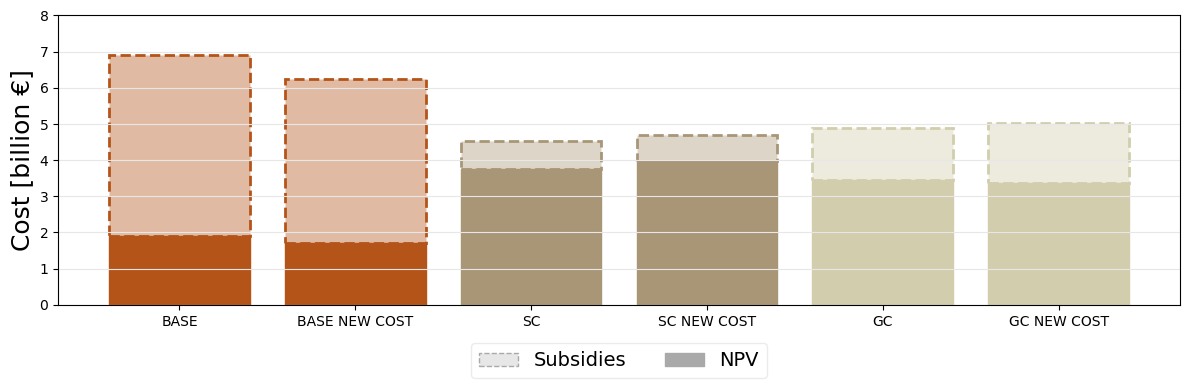

In [102]:
# PLOT NPV AND SUBSIDIES TECH COST SENSITIVITY ANALYSIS

yearly_costs_all = pd.read_csv(path + 'total_costs.csv')
capcost = pd.read_csv(path + 'capcost.csv')

yearly_costs_cost = yearly_costs_all[scenarios_cost]
total_costs_cost = yearly_costs_cost.sum(axis=0) /1000
total_costs_cost.columns = labels_cost

costs_dict_cost = {label: total_costs_cost[i] for i, label in enumerate(yearly_costs_cost.columns)}
costs_df_cost = pd.DataFrame([costs_dict_cost])

subsidies_all = pd.read_csv(path + 'subsidies.csv')
subsidies_cost = subsidies_all[scenarios_cost]
subsidies_cost = subsidies_cost / 1000
print(subsidies_cost)
#subsidies_cost.columns = labels_cost

# Create a new figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 4))

# The x-axis positions for each bar
index = np.arange(len(costs_df_cost.columns))
colors_cost = [brown2, brown2, beige2, beige2, beige3, beige3]

total_costs_bars = ax.bar(index, costs_df_cost.iloc[0], label='NPV', color=colors_cost, edgecolor=colors_cost)

fill_colors_with_alpha = [mcolors.to_rgba(color, alpha=0.4) for color in colors_cost]  # Fill colors with transparency
solid_edge_colors = [mcolors.to_rgba(color, alpha=1) for color in colors_cost]  # Edge colors without transparency



# Plotting the subsidies bars on top of the total costs (NPV)
subsidies_bars = ax.bar(index, subsidies_cost.iloc[0], label='Subsidies', bottom=costs_df_cost.iloc[0], 
                        color=fill_colors_with_alpha, edgecolor=solid_edge_colors, linestyle='--', linewidth=2)

ax.set_xticks(index, fontsize=14)
ax.set_xticklabels(labels_cost, rotation=0)

# # Set the y-axis label
npv_patch = mpatches.Patch(color='darkgrey', label='NPV')
subsidies_patch = mpatches.Patch(facecolor=grey1, edgecolor='darkgrey', linestyle='--', linewidth=1, label='Subsidies')

# Create the legend with custom patches
plt.legend(handles=[subsidies_patch, npv_patch], loc='upper center', edgecolor=grey1, bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)
plt.ylabel('Cost [billion €]', fontsize=18)


# Add a title and a legend

plt.ylim(0,8)
plt.grid(axis='y', color=grey1)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig(fig_path + 'cost/' + 'costs.png', dpi=300, bbox_inches='tight')
plt.show()

## Table 6

In [103]:
# RENEWABLES SHARE IN 2040 WEATHER SENSITIVITY ANALYSIS

production_base = pd.read_csv(path + base_file_name + '_production.csv', index_col=0)
production_base_2011 = pd.read_csv(path + base_2011_file_name + '_production.csv', index_col=0)
production_base_2018 = pd.read_csv(path + base_2018_file_name + '_production.csv', index_col=0)
production_sudden = pd.read_csv(path + sudden_file_name + '_production.csv', index_col=0)
production_sudden_2011 = pd.read_csv(path + sudden_2011_file_name + '_production.csv', index_col=0)
production_sudden_2018 = pd.read_csv(path + sudden_2018_file_name + '_production.csv', index_col=0)

scenario_production = {
    'BASE 2013': production_base,
    'BASE 2011': production_base_2011,
    'BASE 2018': production_base_2018,
    'SC 2013': production_sudden,
    'SC 2011': production_sudden_2011,
    'SC 2018': production_sudden_2018
}

renewables_share_df_2040 = pd.DataFrame({
    'Scenario': list(scenario_production.keys()),
    'Renewables share [%]': [
        (df.loc[final_year, ['Wind', 'Solar', 'Hydro', 'Biomass', 'Geothermal']].sum() / df.loc[final_year].sum()) * 100
        for df in scenario_production.values()
    ]
})

renewables_share_df_2040['Renewables share [%]'] = renewables_share_df_2040['Renewables share [%]'].round(2)
renewables_share_df_2040

,Scenario,Renewables share [%]
0,BASE 2013,20.21
1,BASE 2011,20.20
2,BASE 2018,20.19
3,SC 2013,94.93
4,SC 2011,94.91
5,SC 2018,95.34


## Figure 20

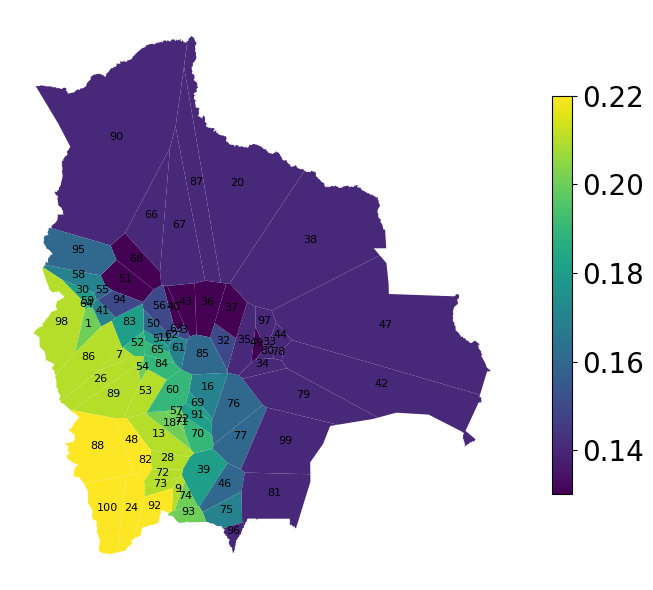

In [104]:
# PLOT SOLAR RADIATION POTENTIAL

all_nodes = pypsa.Network("../final_results/base/B_2040.nc")
generators = all_nodes.generators

plot_capfacs_solar = (
    "solar"  # colors in the back represent capacity factors for this technology
)
plot_capfacs_onwind = (
    "onwind"  # colors in the back represent capacity factors for this technology
)

rel_col = all_nodes.generators_t.p_max_pu.columns#[:252]
cap_n27 = all_nodes.generators_t.p_max_pu[rel_col].mean()
std_n27 = all_nodes.generators_t.p_max_pu[rel_col].std()

std_onwind = std_n27.filter(like=plot_capfacs_onwind).round(2)
std_solar = std_n27.filter(like=plot_capfacs_solar).round(2)
std_onwind.index = [generators.loc[idx, "bus"] for idx in std_onwind.index]
std_solar.index = [generators.loc[idx, "bus"] for idx in std_solar.index]

std_rnw = pd.DataFrame([std_onwind, std_solar], index = ['Standard deviation wind', 'Standard deviation solar']).T

factor_solar = cap_n27.filter(like=plot_capfacs_solar).round(2) 
factor_wind = cap_n27.filter(like=plot_capfacs_onwind).round(2)
factor_solar.index = [generators.loc[idx, "bus"] for idx in factor_solar.index]
factor_wind.index = [generators.loc[idx, "bus"] for idx in factor_wind.index]

mean_cf = pd.DataFrame([factor_wind, factor_solar], index = ['Capacity factor wind', 'Capacity factor solar']).T

table_std_cf = pd.concat([mean_cf, std_rnw], axis = 1).round(2)

table_std_cf = table_std_cf.reset_index()
table_std_cf = table_std_cf.rename(columns = {'index':'Bus'})
# Convert 'Bus' to integers
table_std_cf['Bus'] = pd.to_numeric(table_std_cf['Bus'], errors='coerce')

# Sort by 'Bus'
table_std_cf = table_std_cf.sort_values(by='Bus')

# If you need 'Bus' to be a string again, convert it back
table_std_cf['Bus'] = table_std_cf['Bus'].astype(str)

zone_data = table_std_cf.copy()

zone_data.to_csv('zone_data.csv')

# It's important to ensure that there are no extra whitespace characters in the column names
zone_data.columns = zone_data.columns.str.strip()

# Load the GeoJSON file
geojson_file_path = '../resources/bus_regions/regions_onshore_elec_s_all.geojson'  # Replace with your path
bus_regions_gdf = gpd.read_file(geojson_file_path)

#print(bus_regions_gdf["name"])

# Ensure the 'name' column in bus_regions_gdf and the 'Bus' column in zone_data have the same data type
bus_regions_gdf['name'] = bus_regions_gdf['name'].astype(int)  # Convert to int if needed
zone_data['Bus'] = zone_data['Bus'].astype(int)  # Also convert to int to match

# Merge the data
bus_regions_gdf['name'] = bus_regions_gdf['name'].astype(int)  # Convert to int if needed
merged_gdf = bus_regions_gdf.merge(zone_data, left_on='name', right_on='Bus', how='left')

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
merged_gdf.plot(ax=ax, column='Capacity factor solar', cmap='viridis', legend=True, legend_kwds={'shrink': 0.7})

# Get the colorbar object and set the font size of the tick labels
cbar_ax = fig.axes[1]  # Colorbar is typically the second axes object in the list
cbar_ax.tick_params(labelsize=20)  # Set the font size of the tick labels


# Adding the zone names
for idx, row in merged_gdf.iterrows():
    ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y, str(row['name']), horizontalalignment='center', fontsize=8)

# Turn off the axis
ax.axis('off')

plt.tight_layout()
plt.savefig(fig_path + '4_nodes/' + 'solar_cf.png', bbox_inches='tight', pad_inches=0, dpi=300)

plt.show()

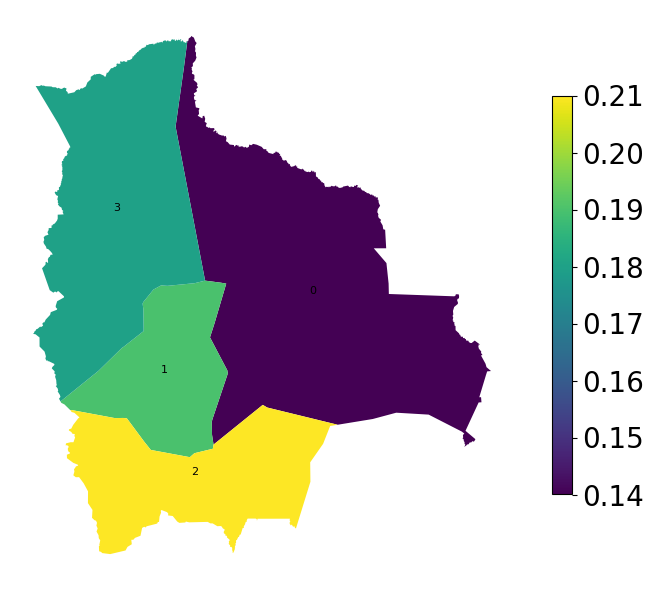

In [105]:
# PLOT SOLAR RADIATION POTENTIAL 4 NODES

four_nodes = pypsa.Network("../final_results/gradual_NZE_4/GCNZE_2040.nc")
generators = four_nodes.generators

plot_capfacs_solar = (
    "solar"  # colors in the back represent capacity factors for this technology
)
plot_capfacs_onwind = (
    "onwind"  # colors in the back represent capacity factors for this technology
)

rel_col = four_nodes.generators_t.p_max_pu.columns#[:252]
cap_n27 = four_nodes.generators_t.p_max_pu[rel_col].mean()
std_n27 = four_nodes.generators_t.p_max_pu[rel_col].std()

std_onwind = std_n27.filter(like=plot_capfacs_onwind).round(2)
std_solar = std_n27.filter(like=plot_capfacs_solar).round(2)
std_onwind.index = [generators.loc[idx, "bus"] for idx in std_onwind.index]
std_solar.index = [generators.loc[idx, "bus"] for idx in std_solar.index]

std_rnw = pd.DataFrame([std_onwind, std_solar], index = ['Standard deviation wind', 'Standard deviation solar']).T

factor_solar = cap_n27.filter(like=plot_capfacs_solar).round(2) 
factor_wind = cap_n27.filter(like=plot_capfacs_onwind).round(2)
factor_solar.index = [generators.loc[idx, "bus"] for idx in factor_solar.index]
factor_wind.index = [generators.loc[idx, "bus"] for idx in factor_wind.index]

mean_cf = pd.DataFrame([factor_wind, factor_solar], index = ['Capacity factor wind', 'Capacity factor solar']).T

table_std_cf = pd.concat([mean_cf, std_rnw], axis = 1).round(2)

table_std_cf = table_std_cf.reset_index()
table_std_cf = table_std_cf.rename(columns = {'index':'Bus'})
# Convert 'Bus' to integers
table_std_cf['Bus'][0] = 0
table_std_cf['Bus'][1] = 1
table_std_cf['Bus'][2] = 2
table_std_cf['Bus'][3] = 3

# Sort by 'Bus'
table_std_cf = table_std_cf.sort_values(by='Bus')

# If you need 'Bus' to be a string again, convert it back
table_std_cf['Bus'] = table_std_cf['Bus'].astype(str)

zone_data = table_std_cf.copy()

zone_data.to_csv('zone_data.csv')

# It's important to ensure that there are no extra whitespace characters in the column names
zone_data.columns = zone_data.columns.str.strip()

# Load the GeoJSON file
geojson_file_path = '../resources/bus_regions/regions_onshore_elec_s_4.geojson'  # Replace with your path
bus_regions_gdf = gpd.read_file(geojson_file_path)

#print(bus_regions_gdf["name"])

# Ensure the 'name' column in bus_regions_gdf and the 'Bus' column in zone_data have the same data type
bus_regions_gdf['name'][0] = 0
bus_regions_gdf['name'][1] = 1
bus_regions_gdf['name'][2] = 2
bus_regions_gdf['name'][3] = 3
zone_data['Bus'] = zone_data['Bus'].astype(int)  # Also convert to int to match

# Merge the data
bus_regions_gdf['name'] = bus_regions_gdf['name'].astype(int)  # Convert to int if needed
merged_gdf = bus_regions_gdf.merge(zone_data, left_on='name', right_on='Bus', how='left')

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8,6))
merged_gdf.plot(ax=ax, column='Capacity factor solar', cmap='viridis', legend=True, legend_kwds={'shrink': 0.7})

# Get the colorbar object and set the font size of the tick labels
cbar_ax = fig.axes[1]  # Colorbar is typically the second axes object in the list
cbar_ax.tick_params(labelsize=20)  # Set the font size of the tick labels


# Adding the zone names
for idx, row in merged_gdf.iterrows():
    ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y, str(row['name']), horizontalalignment='center', fontsize=8)

# Turn off the axis
ax.axis('off')

plt.tight_layout()
plt.savefig(fig_path + '4_nodes/' + 'solar_cf_4.png', bbox_inches='tight', pad_inches=0, dpi=300)

plt.show()

## Figure 21

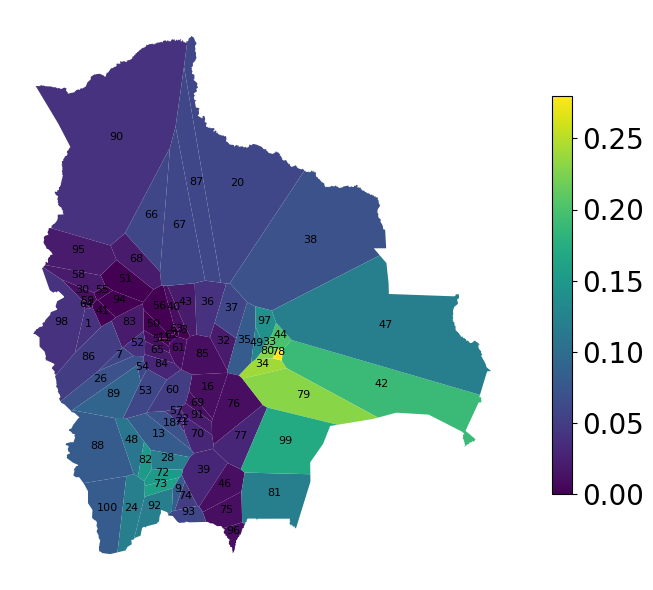

In [106]:
# PLOT WIND POTENTIAL

all_nodes = pypsa.Network("../final_results/base/B_2040.nc")
generators = all_nodes.generators

plot_capfacs_solar = (
    "solar"  # colors in the back represent capacity factors for this technology
)
plot_capfacs_onwind = (
    "onwind"  # colors in the back represent capacity factors for this technology
)

rel_col = all_nodes.generators_t.p_max_pu.columns#[:252]
cap_n27 = all_nodes.generators_t.p_max_pu[rel_col].mean()
std_n27 = all_nodes.generators_t.p_max_pu[rel_col].std()

std_onwind = std_n27.filter(like=plot_capfacs_onwind).round(2)
std_solar = std_n27.filter(like=plot_capfacs_solar).round(2)
std_onwind.index = [generators.loc[idx, "bus"] for idx in std_onwind.index]
std_solar.index = [generators.loc[idx, "bus"] for idx in std_solar.index]

std_rnw = pd.DataFrame([std_onwind, std_solar], index = ['Standard deviation wind', 'Standard deviation solar']).T

factor_solar = cap_n27.filter(like=plot_capfacs_solar).round(2) 
factor_wind = cap_n27.filter(like=plot_capfacs_onwind).round(2)
factor_solar.index = [generators.loc[idx, "bus"] for idx in factor_solar.index]
factor_wind.index = [generators.loc[idx, "bus"] for idx in factor_wind.index]

mean_cf = pd.DataFrame([factor_wind, factor_solar], index = ['Capacity factor wind', 'Capacity factor solar']).T

table_std_cf = pd.concat([mean_cf, std_rnw], axis = 1).round(2)

table_std_cf = table_std_cf.reset_index()
table_std_cf = table_std_cf.rename(columns = {'index':'Bus'})
# Convert 'Bus' to integers
table_std_cf['Bus'] = pd.to_numeric(table_std_cf['Bus'], errors='coerce')

# Sort by 'Bus'
table_std_cf = table_std_cf.sort_values(by='Bus')

# If you need 'Bus' to be a string again, convert it back
table_std_cf['Bus'] = table_std_cf['Bus'].astype(str)

zone_data = table_std_cf.copy()

zone_data.to_csv('zone_data.csv')

zone_data.columns = zone_data.columns.str.strip()

# Load the GeoJSON file
geojson_file_path = '../resources/bus_regions/regions_onshore_elec_s_all.geojson'  # Replace with your path
bus_regions_gdf = gpd.read_file(geojson_file_path)

# Ensure the 'name' column in bus_regions_gdf and the 'Bus' column in zone_data have the same data type
bus_regions_gdf['name'] = bus_regions_gdf['name'].astype(int)  # Convert to int if needed
zone_data['Bus'] = zone_data['Bus'].astype(int)  # Also convert to int to match

# Merge the data
bus_regions_gdf['name'] = bus_regions_gdf['name'].astype(int)  # Convert to int if needed
merged_gdf = bus_regions_gdf.merge(zone_data, left_on='name', right_on='Bus', how='left')

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
merged_gdf.plot(ax=ax, column='Capacity factor wind', cmap='viridis', legend=True, legend_kwds={'shrink': 0.7})

# Get the colorbar object and set the font size of the tick labels
cbar_ax = fig.axes[1]  # Colorbar is typically the second axes object in the list
cbar_ax.tick_params(labelsize=20)  # Set the font size of the tick labels

# Adding the zone names
for idx, row in merged_gdf.iterrows():
    ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y, str(row['name']), horizontalalignment='center', fontsize=8)

# Turn off the axis
ax.axis('off')

plt.tight_layout()
plt.savefig(fig_path + '4_nodes/' + 'wind_cf.png', bbox_inches='tight', pad_inches=0, dpi=300)

plt.show()

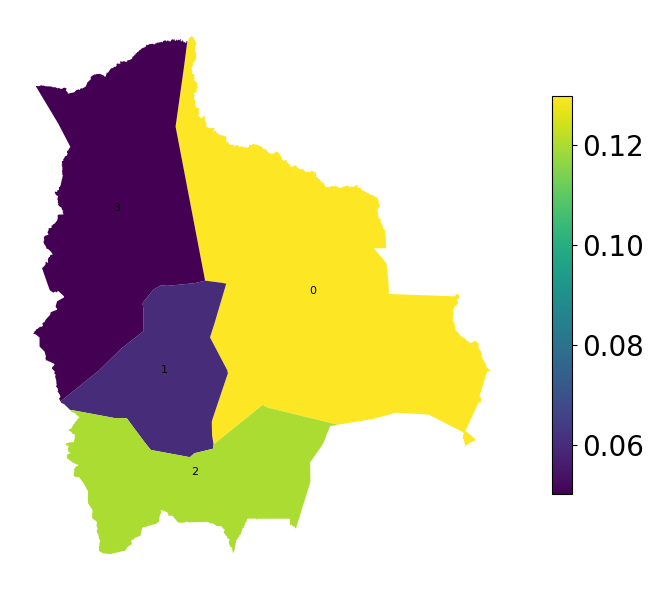

In [107]:
# PLOT WIND POTENTIAL 4 NODES

four_nodes = pypsa.Network("../final_results/gradual_NZE_4/GCNZE_2040.nc")
generators = four_nodes.generators

plot_capfacs_solar = (
    "solar"  # colors in the back represent capacity factors for this technology
)
plot_capfacs_onwind = (
    "onwind"  # colors in the back represent capacity factors for this technology
)

rel_col = four_nodes.generators_t.p_max_pu.columns#[:252]
cap_n27 = four_nodes.generators_t.p_max_pu[rel_col].mean()
std_n27 = four_nodes.generators_t.p_max_pu[rel_col].std()

std_onwind = std_n27.filter(like=plot_capfacs_onwind).round(2)
std_solar = std_n27.filter(like=plot_capfacs_solar).round(2)
std_onwind.index = [generators.loc[idx, "bus"] for idx in std_onwind.index]
std_solar.index = [generators.loc[idx, "bus"] for idx in std_solar.index]

std_rnw = pd.DataFrame([std_onwind, std_solar], index = ['Standard deviation wind', 'Standard deviation solar']).T

factor_solar = cap_n27.filter(like=plot_capfacs_solar).round(2) 
factor_wind = cap_n27.filter(like=plot_capfacs_onwind).round(2)
factor_solar.index = [generators.loc[idx, "bus"] for idx in factor_solar.index]
factor_wind.index = [generators.loc[idx, "bus"] for idx in factor_wind.index]

mean_cf = pd.DataFrame([factor_wind, factor_solar], index = ['Capacity factor wind', 'Capacity factor solar']).T

table_std_cf = pd.concat([mean_cf, std_rnw], axis = 1).round(2)

table_std_cf = table_std_cf.reset_index()
table_std_cf = table_std_cf.rename(columns = {'index':'Bus'})
# Convert 'Bus' to integers
table_std_cf['Bus'][0] = 0
table_std_cf['Bus'][1] = 1
table_std_cf['Bus'][2] = 2
table_std_cf['Bus'][3] = 3

# Sort by 'Bus'
table_std_cf = table_std_cf.sort_values(by='Bus')

# If you need 'Bus' to be a string again, convert it back
table_std_cf['Bus'] = table_std_cf['Bus'].astype(str)

zone_data = table_std_cf.copy()

zone_data.to_csv('zone_data.csv')


zone_data.columns = zone_data.columns.str.strip()

# Load the GeoJSON file
geojson_file_path = '../resources/bus_regions/regions_onshore_elec_s_4.geojson'  # Replace with your path
bus_regions_gdf = gpd.read_file(geojson_file_path)

# Ensure the 'name' column in bus_regions_gdf and the 'Bus' column in zone_data have the same data type
bus_regions_gdf['name'][0] = 0
bus_regions_gdf['name'][1] = 1
bus_regions_gdf['name'][2] = 2
bus_regions_gdf['name'][3] = 3
zone_data['Bus'] = zone_data['Bus'].astype(int)  # Also convert to int to match

# Merge the data
bus_regions_gdf['name'] = bus_regions_gdf['name'].astype(int)  # Convert to int if needed
merged_gdf = bus_regions_gdf.merge(zone_data, left_on='name', right_on='Bus', how='left')

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8,6))
merged_gdf.plot(ax=ax, column='Capacity factor wind', cmap='viridis', legend=True, legend_kwds={'shrink': 0.7})

# Get the colorbar object and set the font size of the tick labels
cbar_ax = fig.axes[1]  # Colorbar is typically the second axes object in the list
cbar_ax.tick_params(labelsize=20)  # Set the font size of the tick labels

# Adding the zone names
for idx, row in merged_gdf.iterrows():
    ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y, str(row['name']), horizontalalignment='center', fontsize=8)

# Turn off the axis
ax.axis('off')

plt.tight_layout()
plt.savefig(fig_path + '4_nodes/' + 'wind_cf_4.png', bbox_inches='tight', pad_inches=0, dpi=300)

plt.show()

## Table 7

In [108]:
# COST TABLE 4 NODES COMPARISON

yearly_costs = pd.read_csv(path + 'total_costs.csv')

yearly_costs_4_nodes = yearly_costs[scenarios_4_nodes]
total_costs_4_nodes = yearly_costs_4_nodes.sum(axis=0) /1000
total_costs_4_nodes.columns = labels_4_nodes
costs_dict_4_nodes = {label: total_costs_4_nodes[i] for i, label in enumerate(yearly_costs_4_nodes.columns)}
costs_df_4_nodes = pd.DataFrame([costs_dict_4_nodes])

opex = pd.read_csv(path + 'opex.csv')
opex_4_nodes = opex[scenarios_4_nodes]
opex_cost_4_nodes = opex_4_nodes.sum(axis=0) / 1000
opex_cost_4_nodes.columns = labels_4_nodes
opex_dict_4_nodes = {label: opex_cost_4_nodes[i] for i, label in enumerate(opex_4_nodes.columns)}
opex_df_4_nodes = pd.DataFrame([opex_dict_4_nodes])

gencost = pd.read_csv(path + 'gencost.csv')
gencost_4_nodes = gencost[scenarios_4_nodes]
gencost_cost_4_nodes = gencost_4_nodes.sum(axis=0) / 1000
gencost_cost_4_nodes.columns = labels_4_nodes
gencost_dict_4_nodes = {label: gencost_cost_4_nodes[i] for i, label in enumerate(gencost_4_nodes.columns)}
gencost_df_4_nodes = pd.DataFrame([gencost_dict_4_nodes])

lines_df = pd.read_csv(path + 'linecost.csv')
lines_4_nodes = lines_df[scenarios_4_nodes]
lines_cost_4_nodes = lines_4_nodes.sum(axis=0) / 1000
lines_cost_4_nodes.columns = labels_4_nodes
lines_dict_4_nodes = {label: lines_cost_4_nodes[i] for i, label in enumerate(lines_4_nodes.columns)}
lines_df_4_nodes = pd.DataFrame([lines_dict_4_nodes])

subsidies_all = pd.read_csv(path + 'subsidies.csv')
subsidies_all = subsidies_all / 1000
subsidies_4_nodes = subsidies_all[scenarios_4_nodes]

cost_table = pd.DataFrame({
    'Scenario': labels_4_nodes,
    'OPEX [billion €]': opex_cost_4_nodes.round(4),
    'Generators CAPEX [billion €]': gencost_df_4_nodes.iloc[0].round(4),
    'Transmission Lines CAPEX [billion €]': lines_df_4_nodes.iloc[0].round(4),
    'Subsidies [billion €]': subsidies_4_nodes.iloc[0].round(4),
    'Total costs [billion €]': (costs_df_4_nodes.iloc[0] + subsidies_4_nodes.iloc[0]).round(4)
})

cost_table.loc[len(cost_table)] = ['Difference (GC NZE - GC NZE 4)', 
                                  (opex_cost_4_nodes.iloc[0] - opex_cost_4_nodes.iloc[1]).round(4), 
                                  (gencost_df_4_nodes.iloc[0, 0] - gencost_df_4_nodes.iloc[0, 1]).round(4), 
                                  (lines_df_4_nodes.iloc[0, 0] - lines_df_4_nodes.iloc[0, 1]).round(4),
                                  (subsidies_4_nodes.iloc[0, 0] - subsidies_4_nodes.iloc[0, 1]).round(4),
                                  ((costs_df_4_nodes.iloc[0, 0] + subsidies_4_nodes.iloc[0, 0]) - (costs_df_4_nodes.iloc[0, 1] + subsidies_4_nodes.iloc[0, 1])).round(4)]

cost_table

,Scenario,OPEX [billion €],Generators CAPEX [billion €],Transmission Lines CAPEX [billion €],Subsidies [billion €],Total costs [billion €]
gradual_NZE,GC NZE,1.2386,2.1275,0.1007,1.2771,4.7438
gradual_NZE_4,GC NZE 4,1.2170,2.1318,0.0256,1.2932,4.6677
2,Difference (GC NZE - GC NZE 4),0.0216,-0.0043,0.0751,-0.0162,0.0761


## Figure 22

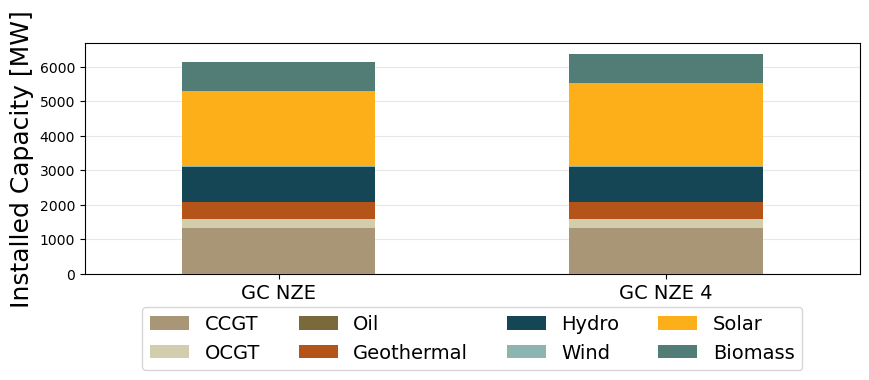

In [109]:
# PLOT FINAL CAPACITY 4 NODES COMPARISON

gradual_final_capacity_cap = pd.read_csv(path + gradual_NZE_file_name + '_final_capacity.csv', index_col=0)
gradual_final_capacity_cap_4 = pd.read_csv(path + gradual_NZE_4_file_name + '_final_capacity.csv', index_col=0)

desired_order = ['CCGT', 'OCGT', 'Oil', 'Geothermal', 'Hydro', 'Wind', 'Solar', 'Biomass']

all_data = pd.concat([gradual_final_capacity_cap, gradual_final_capacity_cap_4], axis=0)
all_data.index = labels_4_nodes
all_data = all_data[desired_order]

ax = all_data.plot(kind='bar', stacked=True, figsize=(10, 3), color=get_colors(all_data.columns), legend=False, zorder=3)   
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=14)
ax.set_ylabel('Installed Capacity [MW]', fontsize=18)   
ax.legend(title='Capacity Type')
plt.legend( loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=14)
plt.grid(axis='y', zorder=0, color=grey1)
plt.savefig(fig_path + '4_nodes/' + 'final_capacity_4.png', dpi=300, bbox_inches='tight')
plt.show()

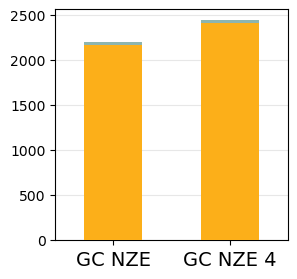

                Solar       Wind
GC NZE    2170.288948  27.000033
GC NZE 4  2414.264901  27.002072


In [110]:
# PLOT FINAL RENEWABLE CAPACITY 4 NODES COMPARISON

gradual_final_capacity_cap = pd.read_csv(path + gradual_NZE_file_name + '_final_capacity.csv', index_col=0)
gradual_final_capacity_cap_4 = pd.read_csv(path + gradual_NZE_4_file_name + '_final_capacity.csv', index_col=0)

desired_order = ['Solar', 'Wind']

all_data = pd.concat([gradual_final_capacity_cap, gradual_final_capacity_cap_4], axis=0)
all_data.index = labels_4_nodes
all_data.pop('CCGT')
all_data.pop('OCGT')
all_data.pop('Oil')
all_data.pop('Geothermal')
all_data.pop('Hydro')
all_data.pop('Biomass')
all_data = all_data[desired_order]

ax = all_data.plot(kind='bar', stacked=True, figsize=(3, 3), color=get_colors(all_data.columns), legend=False, zorder=3)   
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=14)
plt.grid(axis='y', zorder=0, color=grey1)
plt.savefig(fig_path + '4_nodes/' + 'final_VRES_4.png', dpi=300, bbox_inches='tight')
plt.show()

print(all_data)

## Figure 23

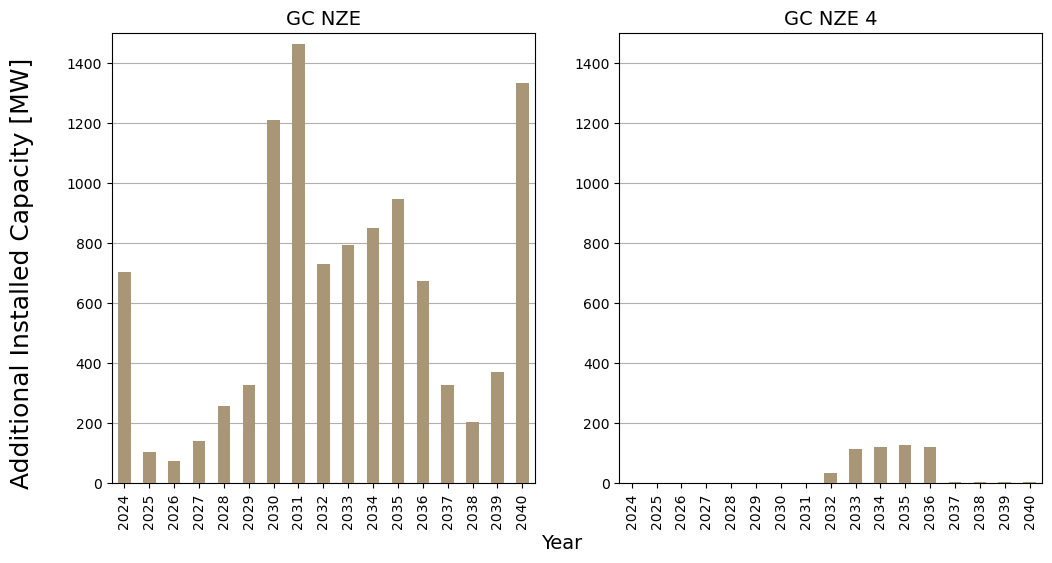

10500.417142801523 522.3557067320027 0.04974618623509633


In [111]:
# PLOT NEW LINE CAPACITY 4 NODES COMPARISON

gradual_line_capacity = pd.read_csv(path + gradual_NZE_file_name + '_new_line_capacity.csv', index_col=0)
gradual_4_line_capacity = pd.read_csv(path + gradual_NZE_4_file_name + '_new_line_capacity.csv', index_col=0)


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axes = axes.flatten()

new_line_scenarios = [
    ('GC NZE', gradual_line_capacity),
    ('GC NZE 4', gradual_4_line_capacity)
]

for ax, (title, line_data) in zip(axes, new_line_scenarios):
    line_data.plot.bar(stacked=True, ax=ax, legend=False, zorder=3, color=beige2)
    ax.set_xlabel('')
    ax.set_xticks(range(len(line_data.index)), fontsize=14)
    ax.set_xticklabels(line_data.index, rotation=90)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(0, 1500)
    ax.grid(axis='y', zorder=0)

# Set the x-axis label on the last subplot
fig.text(0.5, 0.04, 'Year', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Additional Installed Capacity [MW]', va='center', rotation='vertical', fontsize=18)

# Adjust the layout
plt.subplots_adjust(hspace=0.3, top=0.9, bottom=0.15)
plt.savefig(fig_path + '4_nodes/' + 'new_line_capacity_4.png', dpi=300, bbox_inches='tight')
plt.show()

print(gradual_line_capacity.sum().sum(), gradual_4_line_capacity.sum().sum(), gradual_4_line_capacity.sum().sum()/gradual_line_capacity.sum().sum())

## Table A.8

In [112]:
# COST TABLE

cost_table = pd.DataFrame({
    'Scenario': labels,
    'NPV [billion €]': costs_df.iloc[0].round(3).values,
    'Subsidies [billion €]': subsidies.iloc[0].round(3).values,
    'Total costs [billion €]': (costs_df.iloc[0] + subsidies.iloc[0]).round(3).values,
})

cost_table

,Scenario,NPV [billion €],Subsidies [billion €],Total costs [billion €]
0,BASE,1.912,4.981,6.893
1,BASE NZE,2.713,2.273,4.986
2,SC,3.755,0.776,4.531
3,SC NZE,3.733,0.688,4.421
4,GC,3.461,1.434,4.894
5,GC NZE,3.467,1.277,4.744


## Table A.9

In [124]:
# COST TABLE DISCOUNT RATE SENSITIVITY ANALYSIS

opex_all = pd.read_csv(path + 'opex.csv')
opex_discount = opex_all[scenarios_discount]
opex_discount = opex_discount.sum(axis=0) / 1000
opex_discount.index = labels_discount

costs_series    = costs_df_discount.iloc[0]
subs_series     = subsidies_discount.iloc[0] if isinstance(subsidies_discount, pd.DataFrame) else subsidies_discount


cost_table_discount = pd.DataFrame({
    'Scenario': labels_discount,
    'CAPEX [billion €]': (costs_series.values-opex_discount.values).round(3),
    'OPEX [billion €]': opex_discount.values.round(3),
    'Subsidies [billion €]': subs_series.values.round(3),
    'Total costs [billion €]': (costs_series.values + subs_series.values).round(3)
})

cost_table_discount

,Scenario,CAPEX [billion €],OPEX [billion €],Subsidies [billion €],Total costs [billion €]
0,BASE 4%,0.130,1.781,4.981,6.893
1,SC 4%,2.922,0.834,0.776,4.531
2,GC 4%,2.115,1.346,1.434,4.894
3,BASE 7%,0.117,1.416,3.953,5.486
4,SC 7%,2.605,0.931,0.754,4.290
5,GC 7%,1.468,1.625,1.475,4.569
6,BASE 10%,0.164,1.127,3.126,4.416
7,SC 10%,1.421,1.799,0.734,3.954
8,GC 10%,0.981,1.688,1.409,4.078


## Figure A.24

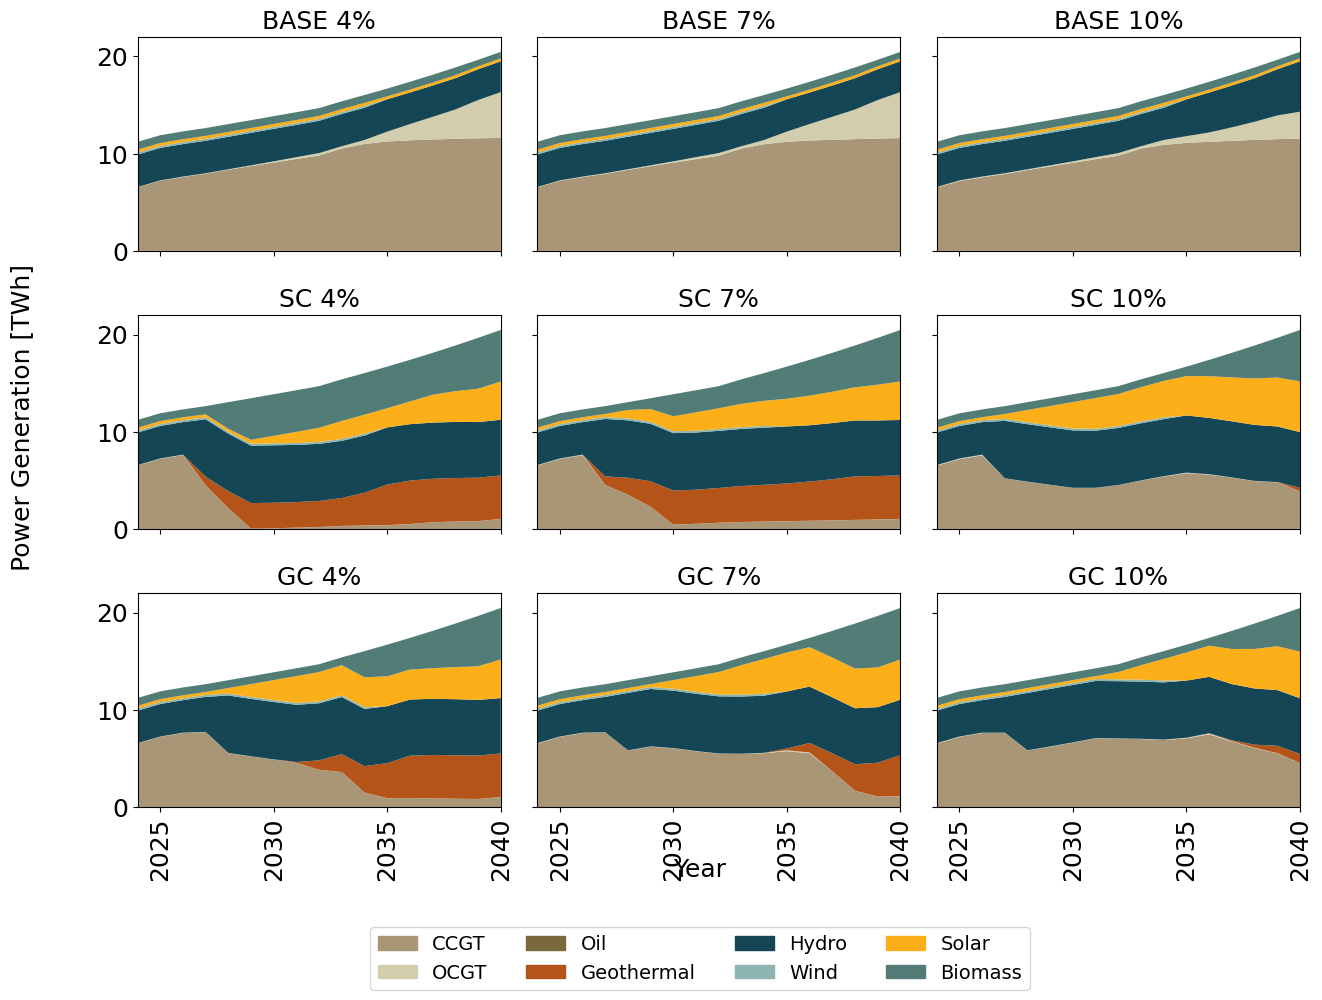

In [114]:
# PLOT PRODUCTION DISCOUNT RATE SENSITIVITY ANALYSIS

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True,
    gridspec_kw={'wspace': 0.1, 'hspace': 0.3})  # Adjust figsize as needed

# Flatten the 2D array of axes to 1D for easier iteration
axes = axes.flatten()

# Define your scenarios
scenarios_prod_discount = [
    (production_base, 'BASE 4%'),    (production_base_007, 'BASE 7%'), (production_base_010, 'BASE 10%'), (production_sudden, 'SC 4%'), (production_sudden_007, 'SC 7%'), (production_sudden_010, 'SC 10%'),
    (production_gradual, 'GC 4%'), (production_gradual_007, 'GC 7%'), (production_gradual_010, 'GC 10%')
]


# Loop through the scenarios to create each subplot
for ax, (production_data, title) in zip(axes, scenarios_prod_discount):
    # Ensure production_data is a DataFrame and not a numpy array
    if isinstance(production_data, pd.DataFrame):
        production_data.index = production_data.index.astype(str).str.strip().astype(int)

        ax.stackplot(production_data.index, production_data.T, 
                     colors=get_colors(production_data.columns), labels=production_data.columns)
        ax.set_ylim(0, 22)
        #ax.set_xlim(first_year, last_year)
        ax.set_title(title, fontsize=18)
        # rotate x-tick labels for better readability including all years
        ax.set_xlim(production_data.index.min(), production_data.index.max())
        xticks = production_data.index[::5]  # hvert 5. element i indeksen
        ax.set_xticks(xticks + 1)
        ax.set_xticklabels(xticks + 1, fontsize=18, rotation=90)
        #ax.tick_params(axis='both', which='major', labelsize=14) 
        ax.tick_params(axis='y', labelsize=18)
    else:
        print(f"Data for {title} is not in DataFrame format.")

# Fjern y-ticks i høyre kolonne
for i, ax in enumerate(axes):
    if i % 3 in [1, 2]:  # høyre kolonne
        ax.set_yticklabels([])
        ax.set_ylabel('')

# Set the shared x and y-axis labels
fig.text(0.5, 0.04, 'Year', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Power Generation [TWh]', va='center', rotation='vertical', fontsize=18)

colors=[beige2,beige3,beige1,brown2, teal2, teal4,yellow,teal3, brown, grey4, grey1]
tech = [label for label in production_base.columns if label != 'Nbattery']  # Exclude 'Nbattery'
patches = [mpatches.Patch(color=color, label=label) for label, color in zip(tech, colors) if label != 'Nbattery']
handles = [mpatches.Patch(color=color, label=label) for label, color in zip(tech, colors)]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, fontsize=14)

#plt.subplots_adjust(hspace=0.3, bottom=0.15)

# Save the figure
plt.savefig(fig_path + 'discount/' + 'power_prod.png', dpi=300, bbox_inches='tight') 
plt.show()

## Figure A.25

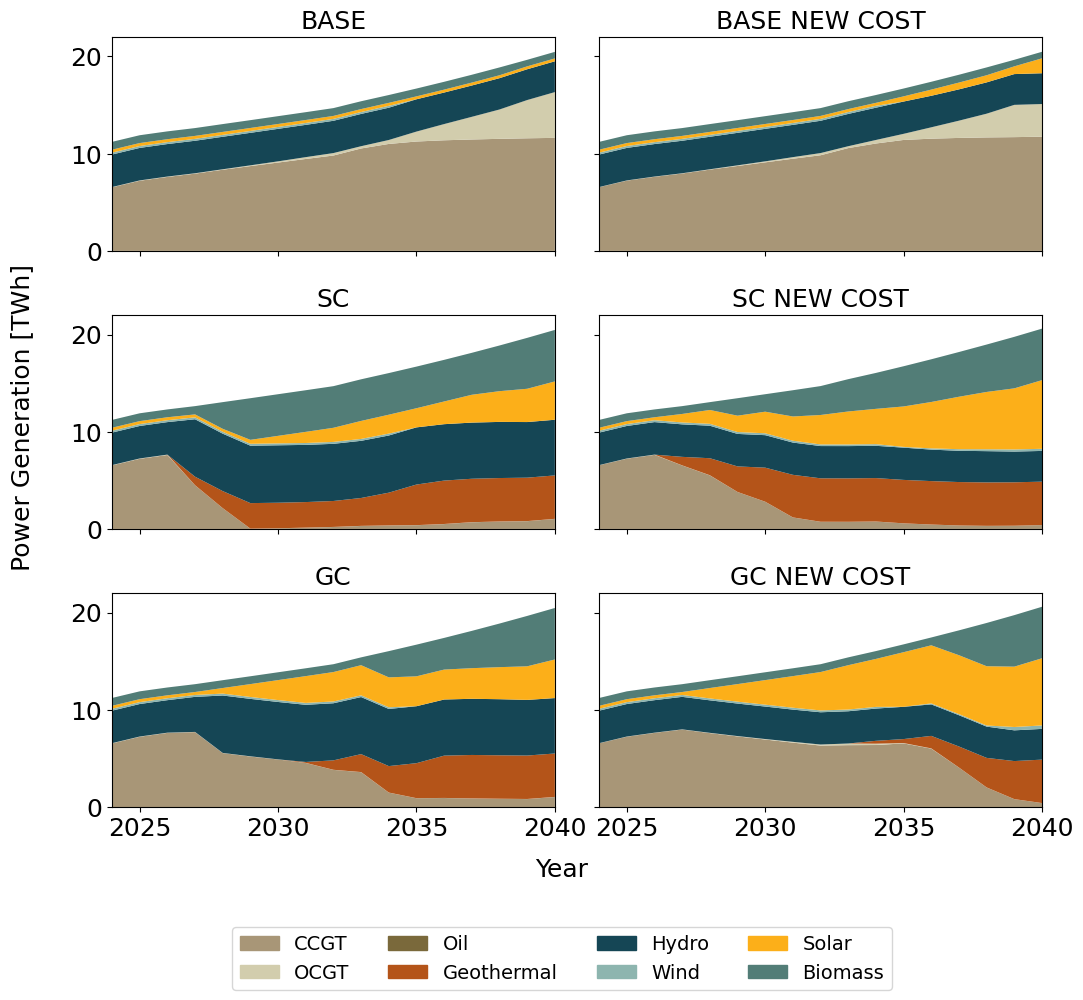

In [115]:
# PLOT PRODUCTION TECH COST SENSITIVITY ANALYSIS

production_base = pd.read_csv(path + base_file_name + '_production.csv', index_col=0)
production_sudden = pd.read_csv(path + sudden_file_name + '_production.csv', index_col=0)
production_gradual = pd.read_csv(path + gradual_file_name + '_production.csv', index_col=0)
production_base_cap = pd.read_csv(path + base_cost_file_name + '_production.csv', index_col=0)
production_sudden_cap = pd.read_csv(path + sudden_cost_file_name + '_production.csv', index_col=0)
production_gradual_cap = pd.read_csv(path + gradual_cost_file_name + '_production.csv', index_col=0)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True,
    gridspec_kw={'wspace': 0.1, 'hspace': 0.3})  # Adjust figsize as needed

# Flatten the 2D array of axes to 1D for easier iteration
axes = axes.flatten()

# Define your scenarios
scenarios_prod_cost = [
    (production_base, 'BASE'),
    (production_base_cap, 'BASE NEW COST'),
    (production_sudden, 'SC'),
    (production_sudden_cap, 'SC NEW COST'),
    (production_gradual, 'GC'),
    (production_gradual_cap, 'GC NEW COST')
]


# Loop through the scenarios to create each subplot
for ax, (production_data, title) in zip(axes, scenarios_prod_cost):
    # Ensure production_data is a DataFrame and not a numpy array
    if isinstance(production_data, pd.DataFrame):
        production_data.index = production_data.index.astype(str).str.strip().astype(int)

        ax.stackplot(production_data.index, production_data.T, 
                     colors=get_colors(production_data.columns), labels=production_data.columns)
        ax.set_ylim(0, 22)
        #ax.set_xlim(first_year, last_year)
        ax.set_title(title, fontsize=18)
        # rotate x-tick labels for better readability including all years
        ax.set_xlim(production_data.index.min(), production_data.index.max())
        xticks = production_data.index[::5]  # hvert 5. element i indeksen
        ax.set_xticks(xticks + 1)
        ax.set_xticklabels(xticks + 1, fontsize=18)
        #ax.tick_params(axis='both', which='major', labelsize=14) 
        ax.tick_params(axis='y', labelsize=18)
    else:
        print(f"Data for {title} is not in DataFrame format.")

# Fjern y-ticks i høyre kolonne
for i, ax in enumerate(axes):
    if i % 2 == 1:  # høyre kolonne
        ax.set_yticklabels([])
        ax.set_ylabel('')

# Set the shared x and y-axis labels
fig.text(0.5, 0.04, 'Year', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Power Generation [TWh]', va='center', rotation='vertical', fontsize=18)

colors=[beige2,beige3,beige1,brown2, teal2, teal4,yellow,teal3, brown, grey4, grey1]
legend = [label for label in production_base.columns if label != 'Nbattery']  # Exclude 'Nbattery'
patches = [mpatches.Patch(color=color, label=label) for label, color in zip(legend, colors) if label != 'Nbattery']
handles = [mpatches.Patch(color=color, label=label) for label, color in zip(legend, colors)]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, fontsize=14)

#plt.subplots_adjust(hspace=0.3, bottom=0.15)

# Save the figure
plt.savefig(fig_path + 'cost/' + 'power_prod.png', dpi=300, bbox_inches='tight') 
plt.show()